在此,我要构建两个神经网络,把宏观模型预测的值作为新的输入,与涨幅因素连接起来.看看是否能起到更好的效果.

实现 **先预测,再修正** 

| 方法 | 思路 | 与你的想法的关系 |
|---|---|---|
| 堆叠泛化，Stacking | 把第一层预测作为第二层的输入，由第二层输出最终预测 | 对应“预测的价值作为新输入” |
| 残差修正，Residual correction | 第一层先预测，第二层预测第一层会错多少，最后相加 | 对应“预测＋修正” |

| 组别 | 设计 | 要回答的问题 |
|---|---|---|
| A | 原7变量基础模型 | 原模型水平是多少？ |
| B | 7变量＋4个涨幅，一层模型 | 直接加涨幅是否已经足够？ |
| C | 第一层预测＋简单线性校准，不含涨幅 | 改善是否只是纠正整体偏高、偏低？ |
| D | 第一层＋涨幅残差修正，不含交互项 | 涨幅能否解释剩余误差？ |
| E | D加入“基础预测×涨幅”交互项 | 涨幅的作用是否取决于基础预测水平？ |
| F | 第一层＋小型神经网络修正 | 更复杂的非线性是否带来额外收益？ |

# 两阶段堆叠模型与单阶段基准：2020年测试，三个种子

本节是实际执行方案；上方其他模型组合保留为历史设想，本次只比较两组。

- **Base**：原7个宏观/价格变量 → 16 → ReLU → 32 → ReLU → 预测股价。
- **Stacking**：冻结上述Base，将其预测股价与金、铜各3个涨幅合并 → 16 → ReLU → 32 → ReLU → 最终股价。第二阶段直接预测股价，不是预测残差。
- 金、铜分别构造 `P(t)/P(t-1)-1`、`P(t)/MA5(t)-1`、`P(t)/MA20(t)-1`，滚动均值包含当日。日指原数据相邻记录，窗口为5/20条记录。
- **按用户要求不用折外预测**：第二阶段用第一阶段对同一训练集的样本内预测，充分利用可用训练数据；第一阶段冻结，两个阶段各训练100轮。
- 训练集为2020年以前，测试集仅2020年。共同剔除涨幅窗口不足或缺失的记录，两个阶段和基准使用相同有效日期。2021年以后不参与本次实验。
- 种子42、7、123；ReLU、Adam、学习率0.01、全批量、标准化目标MSE训练，按原股价尺度计算MAPE（百分数，越低越好）。所有标准化器仅拟合训练集。
- “单阶段”基准本身也有16和32两个隐藏层。堆叠第一阶段直接复用对应种子的基准，保证比较一致。

沿用原数据**同日股价**目标：这不是次日预测。样本内堆叠可能使训练误差偏乐观，结论以2020年测试误差为准，不使用测试集选择轮数或种子。


In [1]:
from pathlib import Path
import os, json, hashlib, random
import numpy as np
import pandas as pd
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display, Image
ROOT=next((p for p in [Path.cwd(), *Path.cwd().parents] if (p/'src/pickle/Dataset.pkl').exists()), Path('/Users/admin/数据分析/ZiJin-Mining/ZiJin-Mining-stock-prediction-'))
OUT=Path(os.environ.get('MLP11_OUT', str(ROOT/'results/mlp_stacking_11')))
OUT.mkdir(parents=True,exist_ok=True)
SEEDS=[42,7,123]; EPOCHS=100; LR=0.01
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
dataset=ROOT/'src/pickle/Dataset.pkl'
d=pd.read_pickle(dataset)
raw=d['X'].copy(); target=d['Y'].copy()
assert raw.index.equals(target.index)
assert raw.index.is_unique and raw.index.is_monotonic_increasing
BASE=list(raw.columns); assert len(BASE)==7
# 截止2020年，先计算纯向后窗口，再分割，测试年初可使用2019年历史。
raw=raw.loc[raw.index.year<=2020]
y=pd.Series(np.asarray(target).reshape(-1),index=target.index,name='Actual').loc[raw.index]
x=raw.copy(); RETURNS=[]
for metal,col in [('gold','Gold Futures Price'),('copper','Copper Futures Price')]:
    name=f'{metal}_daily'; x[name]=raw[col]/raw[col].shift(1)-1; RETURNS.append(name)
    for k in [5,20]:
        name=f'{metal}_vs_ma{k}'
        x[name]=raw[col]/raw[col].rolling(k,min_periods=k).mean()-1
        RETURNS.append(name)
valid=np.isfinite(x.to_numpy()).all(axis=1)&np.isfinite(y.to_numpy())
x=x.loc[valid]; y=y.loc[x.index]
tr=x.index[x.index.year<2020]; te=x.index[x.index.year==2020]
assert len(tr)>0 and len(te)>0 and tr.max()<te.min() and (y>0).all()
splits=pd.DataFrame([dict(Split=s,N=len(idx),Start=str(idx.min().date()),End=str(idx.max().date())) for s,idx in [('Train',tr),('Test',te)]])
splits.to_csv(OUT/'splits.csv',index=False)
x.join(y).to_csv(OUT/'features_and_target.csv',index_label='Date')
config=dict(seeds=SEEDS,epochs_per_stage=EPOCHS,hidden=[16,32],activation='ReLU',optimizer='Adam',lr=LR,batch='full',train_loss='standardized target MSE',metric='MAPE percent',test_year=2020,base_features=BASE,stage2_features=['base_prediction']+RETURNS,stage2_training='in-sample predictions, no OOF',ma_includes_current=True,target='same-date original price',dataset_sha256=hashlib.sha256(dataset.read_bytes()).hexdigest(),torch_version=str(torch.__version__))
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
display(splits)
display(pd.DataFrame({'Stage2 input':config['stage2_features']}))


,Split,N,Start,End
0,Train,2035,2012-06-05,2019-12-31
1,Test,271,2020-01-01,2020-12-31


,Stage2 input
0,base_prediction
1,gold_daily
2,gold_vs_ma5
3,gold_vs_ma20
4,copper_daily
5,copper_vs_ma5
6,copper_vs_ma20


In [2]:
history=[]
def fit_model(X,Y,seed,label):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    sx=StandardScaler().fit(X); sy=StandardScaler().fit(np.asarray(Y).reshape(-1,1))
    xt=torch.tensor(sx.transform(X),dtype=torch.float32)
    yt=torch.tensor(sy.transform(np.asarray(Y).reshape(-1,1)),dtype=torch.float32)
    model=nn.Sequential(nn.Linear(X.shape[1],16),nn.ReLU(),nn.Linear(16,32),nn.ReLU(),nn.Linear(32,1))
    opt=torch.optim.Adam(model.parameters(),lr=LR)
    for epoch in range(1,EPOCHS+1):
        model.train(); opt.zero_grad()
        loss=((model(xt)-yt)**2).mean(); assert torch.isfinite(loss)
        loss.backward(); opt.step()
        model.eval()
        with torch.no_grad(): mse=((model(xt)-yt)**2).mean().item()
        history.append(dict(Seed=seed,Stage=label,Epoch=epoch,Train_MSE=mse))
    return model,sx,sy

def predict(bundle,X):
    model,sx,sy=bundle
    model.eval()
    with torch.no_grad(): z=model(torch.tensor(sx.transform(X),dtype=torch.float32)).numpy()
    p=sy.inverse_transform(z).ravel(); assert np.isfinite(p).all()
    return p

def save_model(bundle,seed,label,features):
    model,sx,sy=bundle
    torch.save(dict(state_dict=model.state_dict(),features=features,seed=seed,epochs=EPOCHS,
                    sx_mean=sx.mean_.tolist(),sx_scale=sx.scale_.tolist(),
                    sy_mean=sy.mean_.tolist(),sy_scale=sy.scale_.tolist(),
                    train_start=str(tr.min()),train_end=str(tr.max())),OUT/f'{label}_seed{seed}.pt')

rows=[]; frames=[]
for seed in SEEDS:
    base=fit_model(x.loc[tr,BASE],y.loc[tr],seed,'Base')
    bp=pd.Series(predict(base,x[BASE]),index=x.index)
    # 用户指定：全训练集样本内预测；不做折外划分、不反向更新第一阶段。
    meta=x[RETURNS].copy(); meta.insert(0,'base_prediction',bp)
    stack=fit_model(meta.loc[tr],y.loc[tr],seed,'Stage2')
    sp=pd.Series(predict(stack,meta),index=x.index)
    save_model(base,seed,'Base',BASE); save_model(stack,seed,'Stage2',list(meta.columns))
    meta.to_csv(OUT/f'stage2_inputs_seed{seed}.csv',index_label='Date')
    for model,pred in [('Base',bp),('Stacking',sp)]:
        for split,idx in [('Train',tr),('Test',te)]:
            actual=y.loc[idx].to_numpy(); p=pred.loc[idx].to_numpy()
            ape=100*np.abs(p-actual)/np.abs(actual)
            rows.append(dict(Seed=seed,Model=model,Split=split,N=len(idx),MAPE=ape.mean()))
            frames.append(pd.DataFrame(dict(Date=idx,Seed=seed,Model=model,Split=split,Actual=actual,Predicted=p,APE=ape)))
    print(f'Seed {seed}: two stages completed, each {EPOCHS} epochs')
metrics=pd.DataFrame(rows); predictions=pd.concat(frames,ignore_index=True)
history=pd.DataFrame(history)
metrics.to_csv(OUT/'metrics.csv',index=False)
predictions.to_csv(OUT/'predictions.csv',index=False)
history.to_csv(OUT/'training_history.csv',index=False)
test=metrics[metrics.Split=='Test']
comparison=test.pivot(index='Seed',columns='Model',values='MAPE').reindex(SEEDS)
comparison['Stacking_minus_Base_pp']=comparison.Stacking-comparison.Base
summary=test.groupby('Model').MAPE.agg(['mean','std','min','max']).reindex(['Base','Stacking'])
comparison.to_csv(OUT/'seed_comparison.csv'); summary.to_csv(OUT/'summary.csv')
assert len(metrics)==12 and len(history)==3*2*100
assert predictions.groupby(['Seed','Model','Split']).size().nunique()==2
print('2020 Test MAPE (%); negative paired difference means stacking improves')
display(comparison.round(4)); display(summary.round(4))
print('Train MAPE (%), based on in-sample predictions:')
display(metrics[metrics.Split=='Train'].pivot(index='Seed',columns='Model',values='MAPE').reindex(SEEDS).round(4))


Model,Base,Stacking,Stacking_minus_Base_pp
Seed,,,
42,12.7949,12.9362,0.1412
7,10.5378,10.4800,-0.0578
123,16.1385,15.9172,-0.2213


,mean,std,min,max
Model,,,,
Base,13.1571,2.8179,10.5378,16.1385
Stacking,13.1111,2.7228,10.4800,15.9172


Model,Base,Stacking
Seed,,
42,2.7657,2.7997
7,2.9166,2.7380
123,2.8893,2.7271


Seed 42: two stages completed, each 100 epochs
Seed 7: two stages completed, each 100 epochs
Seed 123: two stages completed, each 100 epochs
2020 Test MAPE (%); negative paired difference means stacking improves
Train MAPE (%), based on in-sample predictions:


## 预测曲线与训练过程

每个种子单独画出2020年预测；汇总值是三个种子的MAPE均值与样本标准差，并非先平均预测再算MAPE。配对差为堆叠MAPE减基准MAPE，负数表示堆叠改善。

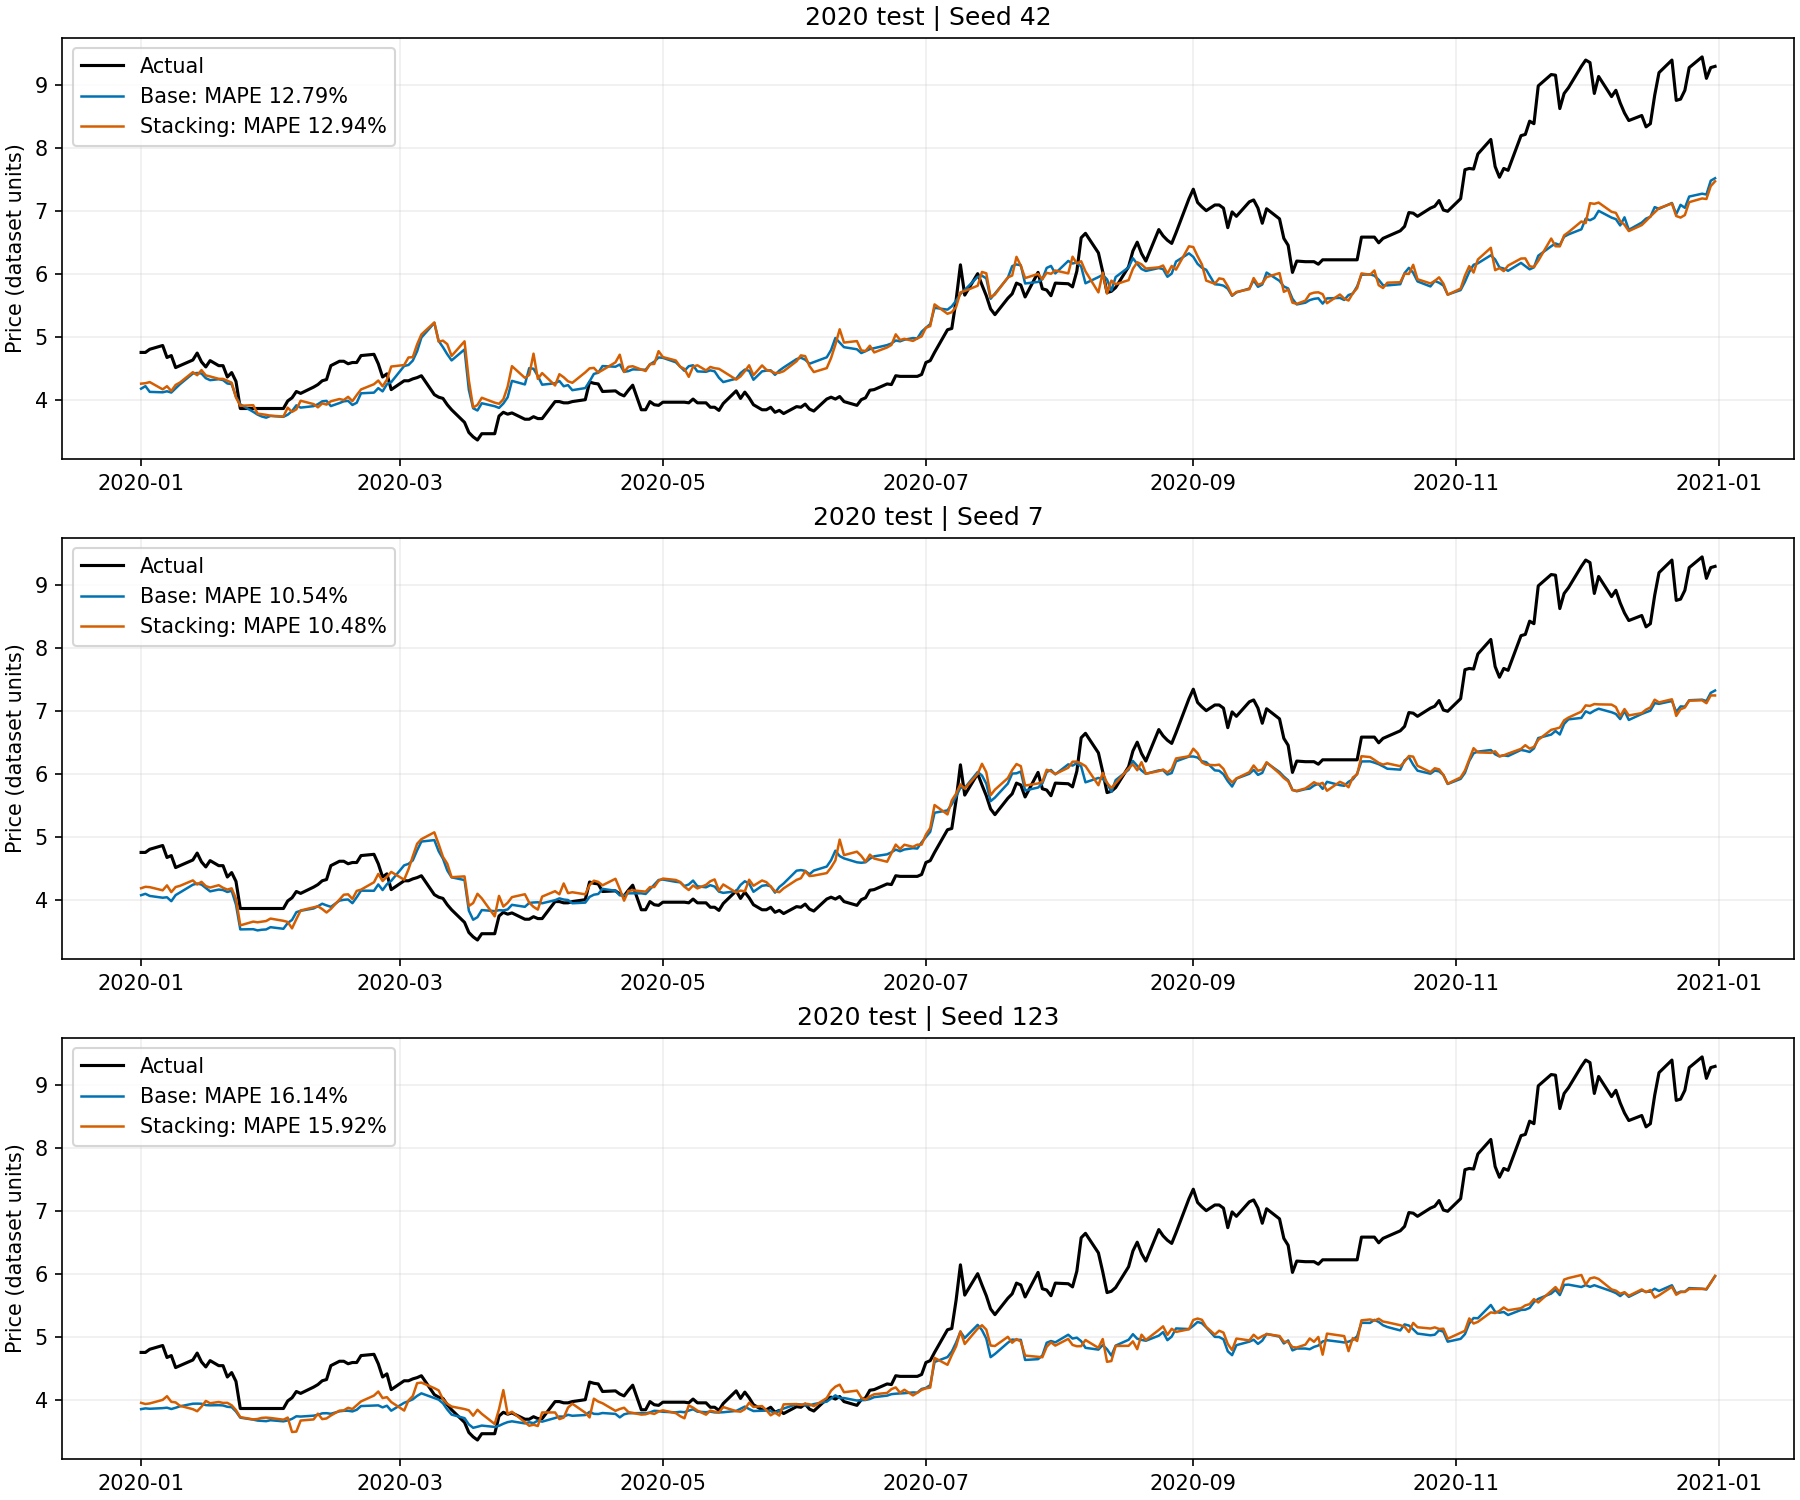

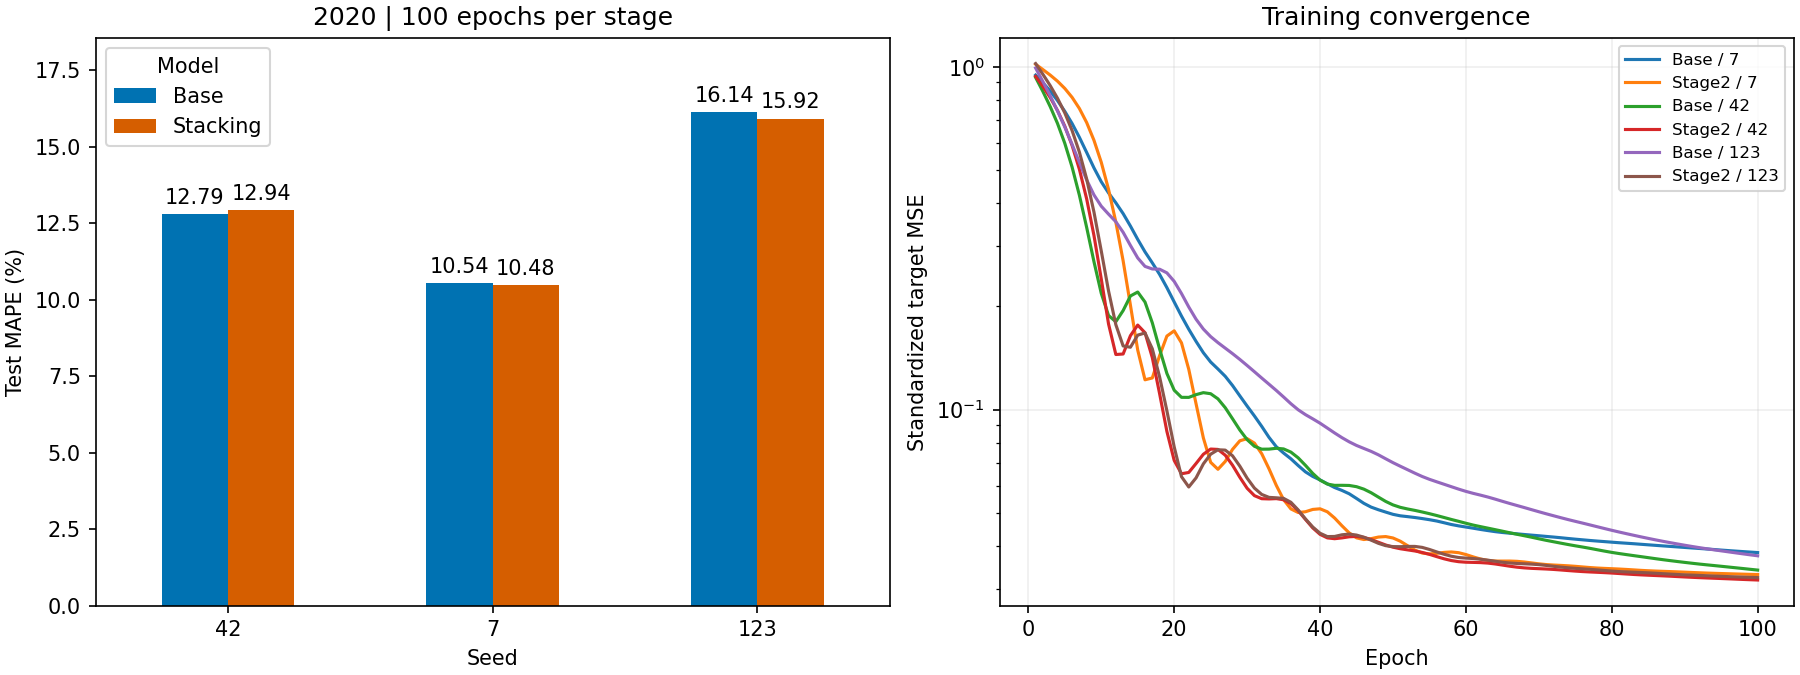

堆叠模型在2/3个种子中测试MAPE更低；平均配对差为-0.0459个百分点。
单个测试年、三个种子只能说明本次设定下的结果，不能据此证明其他年份也更好。


In [3]:
fig,axes=plt.subplots(3,1,figsize=(12,10),constrained_layout=True)
for ax,seed in zip(axes,SEEDS):
    ax.plot(te,y.loc[te],color='black',lw=1.5,label='Actual')
    for name,color in [('Base','#0072B2'),('Stacking','#D55E00')]:
        g=predictions[(predictions.Seed==seed)&(predictions.Model==name)&(predictions.Split=='Test')]
        ax.plot(g.Date,g.Predicted,color=color,lw=1.2,label=f'{name}: MAPE {comparison.loc[seed,name]:.2f}%')
    ax.set(title=f'2020 test | Seed {seed}',ylabel='Price (dataset units)'); ax.legend(); ax.grid(alpha=.2)
fig.savefig(OUT/'predictions_2020.png',dpi=150); plt.close(fig)
display(Image(filename=str(OUT/'predictions_2020.png')))
fig,axes=plt.subplots(1,2,figsize=(12,4.5),constrained_layout=True)
comparison[['Base','Stacking']].plot.bar(ax=axes[0],rot=0,color=['#0072B2','#D55E00'])
axes[0].set(ylabel='Test MAPE (%)',title='2020 | 100 epochs per stage')
for c in axes[0].containers: axes[0].bar_label(c,fmt='%.2f',padding=3)
axes[0].margins(y=.15)
for (seed,stage),g in history.groupby(['Seed','Stage']):
    axes[1].plot(g.Epoch,g.Train_MSE,label=f'{stage} / {seed}')
axes[1].set(xlabel='Epoch',ylabel='Standardized target MSE',yscale='log',title='Training convergence')
axes[1].legend(fontsize=8); axes[1].grid(alpha=.2)
fig.savefig(OUT/'comparison.png',dpi=150); plt.close(fig)
display(Image(filename=str(OUT/'comparison.png')))
monthly=predictions[predictions.Split=='Test'].copy()
monthly['Month']=monthly.Date.dt.strftime('%Y-%m')
monthly=monthly.groupby(['Month','Seed','Model']).APE.mean().unstack('Model')
monthly.to_csv(OUT/'monthly_mape.csv')
mean_delta=comparison.Stacking_minus_Base_pp.mean()
wins=int((comparison.Stacking_minus_Base_pp<0).sum())
print(f'堆叠模型在{wins}/3个种子中测试MAPE更低；平均配对差为{mean_delta:+.4f}个百分点。')
print('单个测试年、三个种子只能说明本次设定下的结果，不能据此证明其他年份也更好。')


## 本次运行结果

| 随机种子 | 基准MAPE (%) | 堆叠MAPE (%) | 堆叠−基准（百分点） |
|---|---:|---:|---:|
|42|12.7949|12.9362|+0.1412|
|7|10.5378|10.4800|−0.0578|
|123|16.1385|15.9172|−0.2213|
|均值|13.1571|13.1111|−0.0459|

三个种子的样本标准差：基准2.8179、堆叠2.7228个百分点。堆叠在2/3个种子上改善，但平均改善仅0.0459个百分点，远小于种子之间的差异，**本次结果未显示明显、稳定的优势**。

训练样本2035条（2012-06-05至2019-12-31），测试样本271条（2020-01-01至2020-12-31）。样本沿用原Dataset的日期对齐，不能把271条直接称为271个A股交易日。没有折外预测，所有有效训练样本都用于两个阶段。


# 堆叠模型训练轮数对比：100 / 200 / 400 / 800

保持前一实验的训练/测试日期、原7个基准输入、金铜6项涨幅、16×32隐藏层、ReLU、Adam学习率0.01、全批量、种子42/7/123不变。**不用折外预测**，第二阶段使用第一阶段对全部有效训练样本的样本内预测。

每组轮数E表示：**第一阶段训练E轮，冻结后生成预测，第二阶段从相同种子的初始状态训练E轮**。第一阶段在同一800轮训练路径上保存四个检查点；不同E的第二阶段因输入预测不同，独立初始化训练。每组总计2E轮，不是两个阶段合计E轮。

2020年为固定测试集；报告所有预先指定轮数，不使用测试集早停或挑选种子。第一阶段基准结果也保留，便于判断第二阶段是否改善。以下单元可单独从本节起运行。


In [1]:
from pathlib import Path
import os, json, hashlib, random
import numpy as np
import pandas as pd
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display, Image
ROOT=next((p for p in [Path.cwd(), *Path.cwd().parents] if (p/'src/pickle/Dataset.pkl').exists()), Path('/Users/admin/数据分析/ZiJin-Mining/ZiJin-Mining-stock-prediction-'))
OUT=Path(os.environ.get('MLP11_EPOCH_OUT', str(ROOT/'results/mlp_stacking_epochs_11')))
OUT.mkdir(parents=True,exist_ok=True)
SEEDS=[42,7,123]; EPOCHS=100; LR=0.01
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
dataset=ROOT/'src/pickle/Dataset.pkl'
d=pd.read_pickle(dataset)
raw=d['X'].copy(); target=d['Y'].copy()
assert raw.index.equals(target.index)
assert raw.index.is_unique and raw.index.is_monotonic_increasing
BASE=list(raw.columns); assert len(BASE)==7
# 截止2020年，先计算纯向后窗口，再分割，测试年初可使用2019年历史。
raw=raw.loc[raw.index.year<=2020]
y=pd.Series(np.asarray(target).reshape(-1),index=target.index,name='Actual').loc[raw.index]
x=raw.copy(); RETURNS=[]
for metal,col in [('gold','Gold Futures Price'),('copper','Copper Futures Price')]:
    name=f'{metal}_daily'; x[name]=raw[col]/raw[col].shift(1)-1; RETURNS.append(name)
    for k in [5,20]:
        name=f'{metal}_vs_ma{k}'
        x[name]=raw[col]/raw[col].rolling(k,min_periods=k).mean()-1
        RETURNS.append(name)
valid=np.isfinite(x.to_numpy()).all(axis=1)&np.isfinite(y.to_numpy())
x=x.loc[valid]; y=y.loc[x.index]
tr=x.index[x.index.year<2020]; te=x.index[x.index.year==2020]
assert len(tr)>0 and len(te)>0 and tr.max()<te.min() and (y>0).all()
splits=pd.DataFrame([dict(Split=s,N=len(idx),Start=str(idx.min().date()),End=str(idx.max().date())) for s,idx in [('Train',tr),('Test',te)]])
splits.to_csv(OUT/'splits.csv',index=False)
x.join(y).to_csv(OUT/'features_and_target.csv',index_label='Date')
config=dict(seeds=SEEDS,epochs_per_stage=EPOCHS,hidden=[16,32],activation='ReLU',optimizer='Adam',lr=LR,batch='full',train_loss='standardized target MSE',metric='MAPE percent',test_year=2020,base_features=BASE,stage2_features=['base_prediction']+RETURNS,stage2_training='in-sample predictions, no OOF',ma_includes_current=True,target='same-date original price',dataset_sha256=hashlib.sha256(dataset.read_bytes()).hexdigest(),torch_version=str(torch.__version__))
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
display(splits)
display(pd.DataFrame({'Stage2 input':config['stage2_features']}))


,Split,N,Start,End
0,Train,2035,2012-06-05,2019-12-31
1,Test,271,2020-01-01,2020-12-31


,Stage2 input
0,base_prediction
1,gold_daily
2,gold_vs_ma5
3,gold_vs_ma20
4,copper_daily
5,copper_vs_ma5
6,copper_vs_ma20


In [2]:
import copy
BUDGETS=[100,200,400,800]
config['epoch_budgets_per_stage']=BUDGETS
config.pop('epochs_per_stage',None)
config['stage1_path']='shared checkpoints within seed'
config['stage2_path']='fresh fit for each budget using corresponding stage1 predictions'
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
H=[]
def train_checkpoints(X,Y,seed,stage,budget,checkpoints):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    sx=StandardScaler().fit(X); sy=StandardScaler().fit(np.asarray(Y).reshape(-1,1))
    xt=torch.tensor(sx.transform(X),dtype=torch.float32)
    yt=torch.tensor(sy.transform(np.asarray(Y).reshape(-1,1)),dtype=torch.float32)
    model=nn.Sequential(nn.Linear(X.shape[1],16),nn.ReLU(),nn.Linear(16,32),nn.ReLU(),nn.Linear(32,1))
    opt=torch.optim.Adam(model.parameters(),lr=LR); saved={}
    for epoch in range(1,max(checkpoints)+1):
        model.train(); opt.zero_grad(); loss=((model(xt)-yt)**2).mean()
        assert torch.isfinite(loss); loss.backward(); opt.step(); model.eval()
        with torch.no_grad(): mse=((model(xt)-yt)**2).mean().item()
        H.append(dict(Seed=seed,Stage=stage,Budget=budget,Epoch=epoch,Train_MSE=mse))
        if epoch in checkpoints: saved[epoch]=(copy.deepcopy(model),sx,sy)
    return saved

def predict_e(bundle,X):
    model,sx,sy=bundle; model.eval()
    with torch.no_grad(): z=model(torch.tensor(sx.transform(X),dtype=torch.float32)).numpy()
    result=sy.inverse_transform(z).ravel(); assert np.isfinite(result).all()
    return pd.Series(result,index=X.index)

def save_e(bundle,seed,stage,budget,features):
    model,sx,sy=bundle
    torch.save(dict(state_dict=model.state_dict(),features=features,seed=seed,epochs=budget,
        hidden=[16,32],sx_mean=sx.mean_.tolist(),sx_scale=sx.scale_.tolist(),
        sy_mean=sy.mean_.tolist(),sy_scale=sy.scale_.tolist(),
        train_start=str(tr.min()),train_end=str(tr.max())),OUT/f'{stage}_{budget}_seed{seed}.pt')

rows=[]; frames=[]
for seed in SEEDS:
    bases=train_checkpoints(x.loc[tr,BASE],y.loc[tr],seed,'Base',800,BUDGETS)
    for budget in BUDGETS:
        base=bases[budget]; bp=predict_e(base,x[BASE])
        meta=x[RETURNS].copy(); meta.insert(0,'base_prediction',bp)
        stack=train_checkpoints(meta.loc[tr],y.loc[tr],seed,'Stage2',budget,[budget])[budget]
        sp=predict_e(stack,meta)
        save_e(base,seed,'Base',budget,BASE); save_e(stack,seed,'Stage2',budget,list(meta.columns))
        for name,pred in [('Base',bp),('Stacking',sp)]:
            for split,idx in [('Train',tr),('Test',te)]:
                actual=y.loc[idx].to_numpy(); p=pred.loc[idx].to_numpy()
                ape=100*np.abs(p-actual)/np.abs(actual)
                rows.append(dict(Seed=seed,Epochs=budget,Model=name,Split=split,N=len(idx),MAPE=ape.mean()))
                frames.append(pd.DataFrame(dict(Date=idx,Seed=seed,Epochs=budget,Model=name,Split=split,Actual=actual,Predicted=p,APE=ape)))
        print(f'Seed {seed}, {budget} epochs per stage completed',flush=True)
metrics_e=pd.DataFrame(rows); predictions_e=pd.concat(frames,ignore_index=True); history_e=pd.DataFrame(H)
metrics_e.to_csv(OUT/'metrics.csv',index=False)
predictions_e.to_csv(OUT/'predictions.csv',index=False)
history_e.to_csv(OUT/'training_history.csv',index=False)
assert len(metrics_e)==3*4*2*2
assert history_e.groupby(['Seed','Stage','Budget']).Epoch.max().tolist().count(800)==6
# 复核100轮与此前实验完全一致（若此前结果存在）。
prior=OUT.parent/'mlp_stacking_11/predictions.csv'
if prior.exists():
    old=pd.read_csv(prior,parse_dates=['Date'])
    new=predictions_e[predictions_e.Epochs==100]
    check=old.merge(new,on=['Date','Seed','Model','Split'],suffixes=('_old','_new'),validate='one_to_one')
    assert len(check)==len(old)==len(new)
    assert np.allclose(check.Actual_old,check.Actual_new,rtol=0,atol=1e-10)
    delta=np.max(np.abs(check.Predicted_old-check.Predicted_new))
    assert delta<1e-4
    print(f'100轮复现检查通过，最大预测差={delta:.8g}')
stack_metrics=metrics_e[metrics_e.Model=='Stacking']
comparison_e=stack_metrics[stack_metrics.Split=='Test'].pivot(index='Seed',columns='Epochs',values='MAPE').reindex(SEEDS)
summary_e=stack_metrics.groupby(['Epochs','Split']).MAPE.agg(['mean','std','min','max'])
paired_e=metrics_e[metrics_e.Split=='Test'].pivot(index=['Epochs','Seed'],columns='Model',values='MAPE')
paired_e['Stacking_minus_Base_pp']=paired_e.Stacking-paired_e.Base
comparison_e.to_csv(OUT/'test_mape_by_seed.csv'); summary_e.to_csv(OUT/'summary.csv'); paired_e.to_csv(OUT/'paired_comparison.csv')
print('堆叠模型2020测试MAPE (%)：'); display(comparison_e.round(4))
print('堆叠模型训练/测试MAPE均值及样本标准差：'); display(summary_e.round(4))
print('同轮数堆叠与第一阶段基准的测试对比：'); display(paired_e.round(4))


Epochs,100,200,400,800
Seed,,,,
42,12.9362,13.3050,12.5285,17.8292
7,10.4800,9.7845,15.6741,24.8620
123,15.9172,15.8298,19.3820,25.8067


mean     std      min      max
Epochs Split                                   
100    Test   13.1111  2.7228  10.4800  15.9172
       Train   2.7549  0.0392   2.7271   2.7997
200    Test   12.9731  3.0363   9.7845  15.8298
       Train   2.2930  0.0327   2.2611   2.3264
400    Test   15.8615  3.4306  12.5285  19.3820
       Train   1.9246  0.0414   1.8857   1.9680
800    Test   22.8326  4.3588  17.8292  25.8067
       Train   1.6387  0.0521   1.6051   1.6988

Model           Base  Stacking  Stacking_minus_Base_pp
Epochs Seed                                           
100    7     10.5378   10.4800                 -0.0578
       42    12.7949   12.9362                  0.1412
       123   16.1385   15.9172                 -0.2213
200    7      9.6727    9.7845                  0.1117
       42    13.3132   13.3050                 -0.0082
       123   15.6207   15.8298                  0.2091
400    7     15.5907   15.6741                  0.0834
       42    12.5932   12.5285                 -0.0647
       123   19.2906   19.3820                  0.0914
800    7     25.0359   24.8620                 -0.1739
       42    17.6403   17.8292                  0.1889
       123   25.6648   25.8067                  0.1419

Seed 42, 100 epochs per stage completed
Seed 42, 200 epochs per stage completed
Seed 42, 400 epochs per stage completed
Seed 42, 800 epochs per stage completed
Seed 7, 100 epochs per stage completed
Seed 7, 200 epochs per stage completed
Seed 7, 400 epochs per stage completed
Seed 7, 800 epochs per stage completed
Seed 123, 100 epochs per stage completed
Seed 123, 200 epochs per stage completed
Seed 123, 400 epochs per stage completed
Seed 123, 800 epochs per stage completed
100轮复现检查通过，最大预测差=2.3800659e-07
堆叠模型2020测试MAPE (%)：
堆叠模型训练/测试MAPE均值及样本标准差：
同轮数堆叠与第一阶段基准的测试对比：


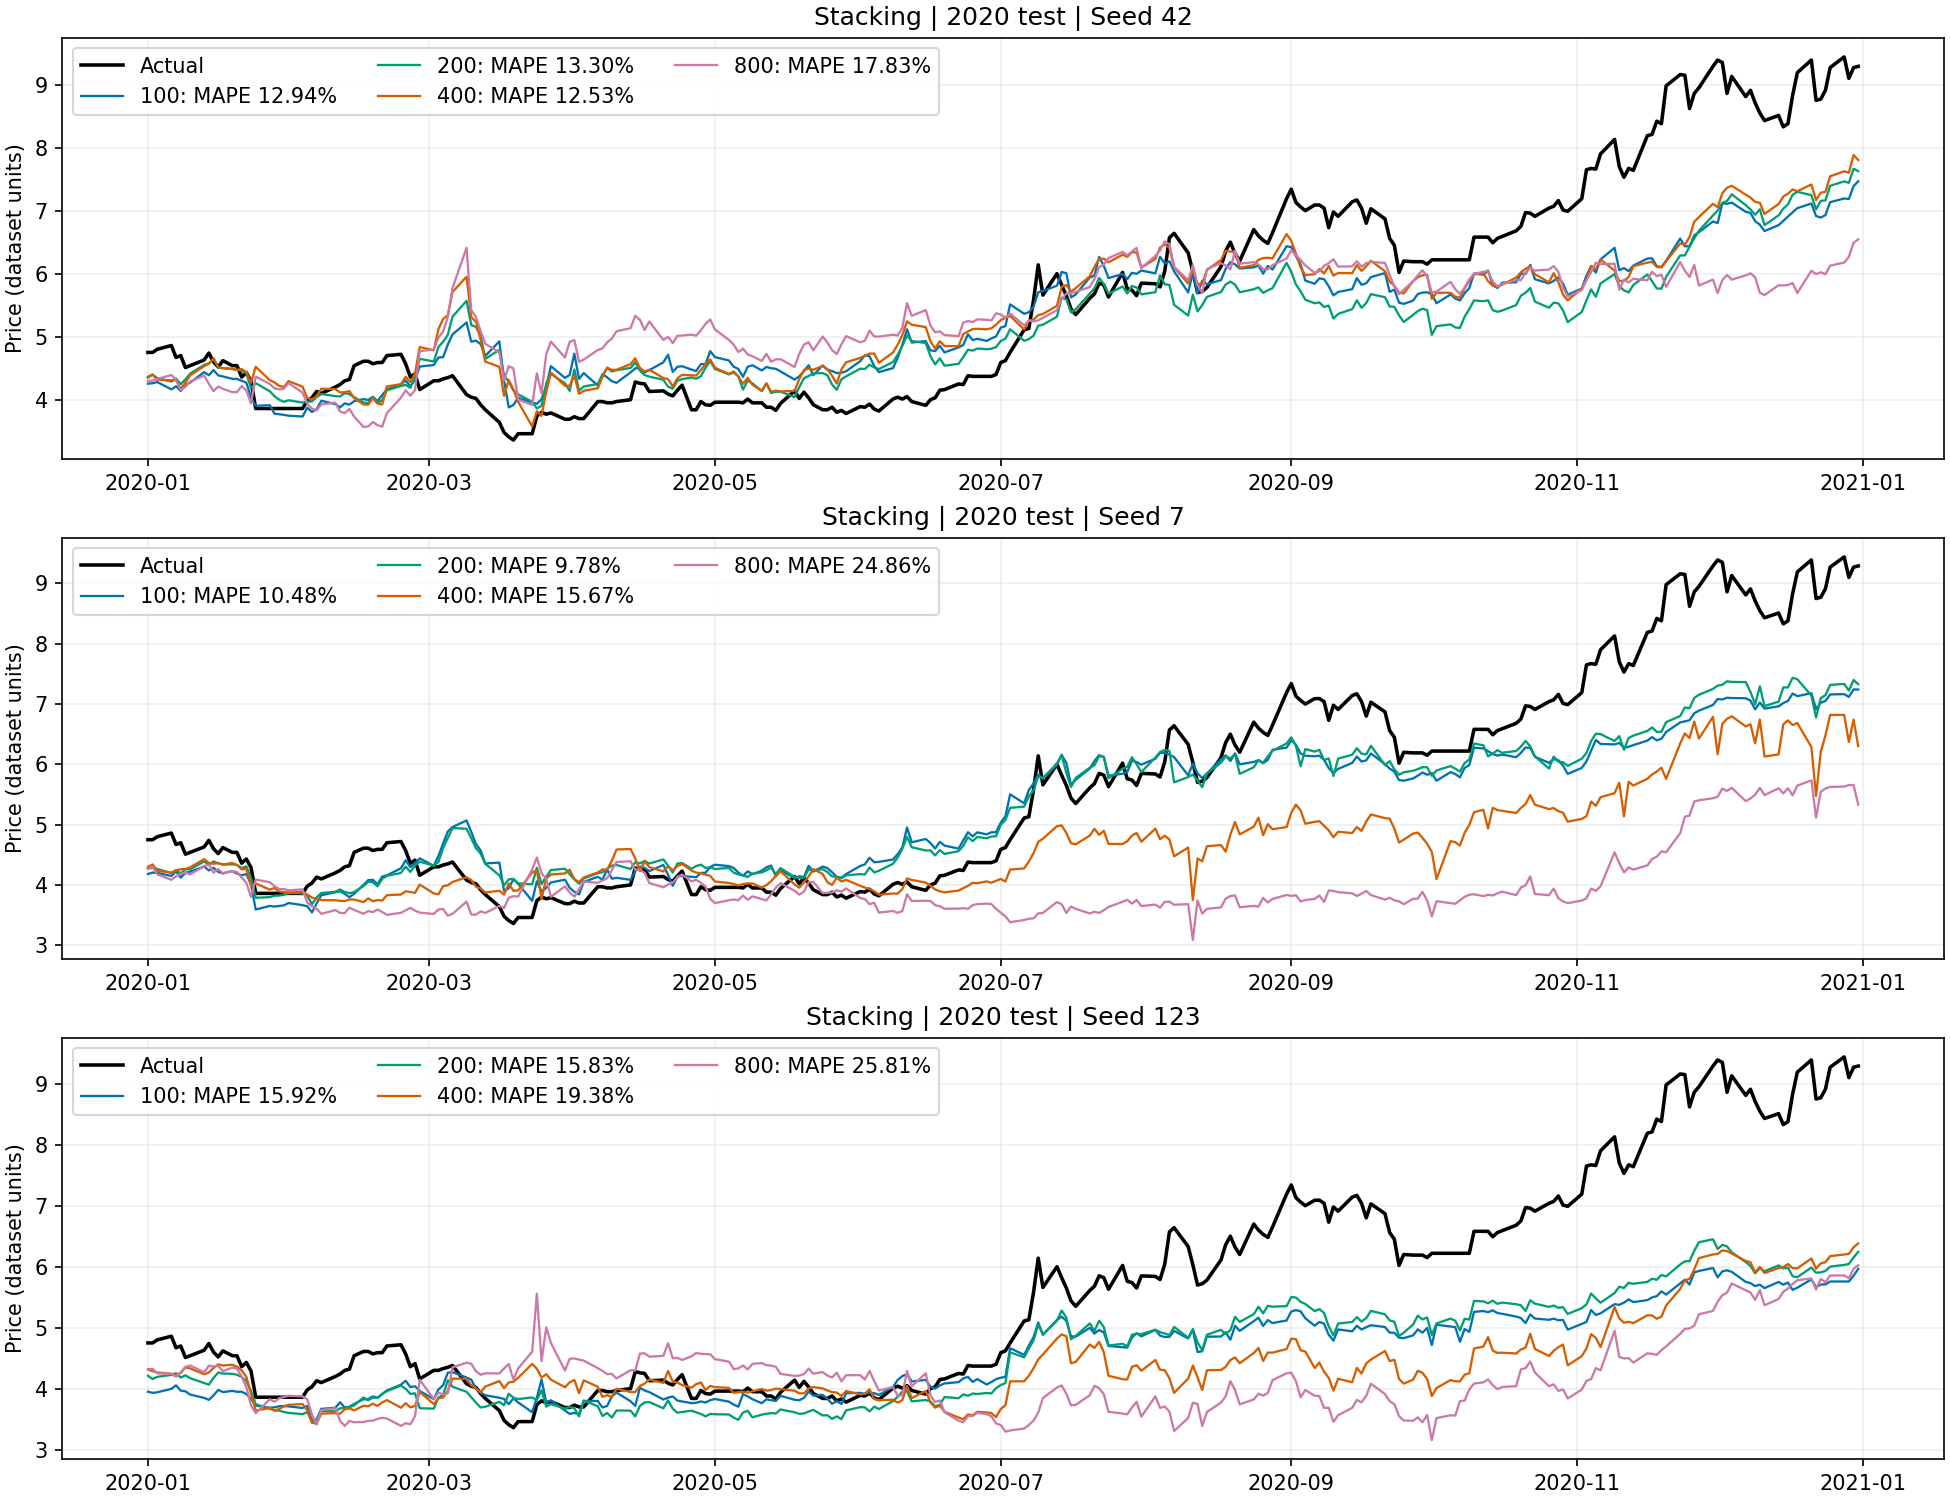

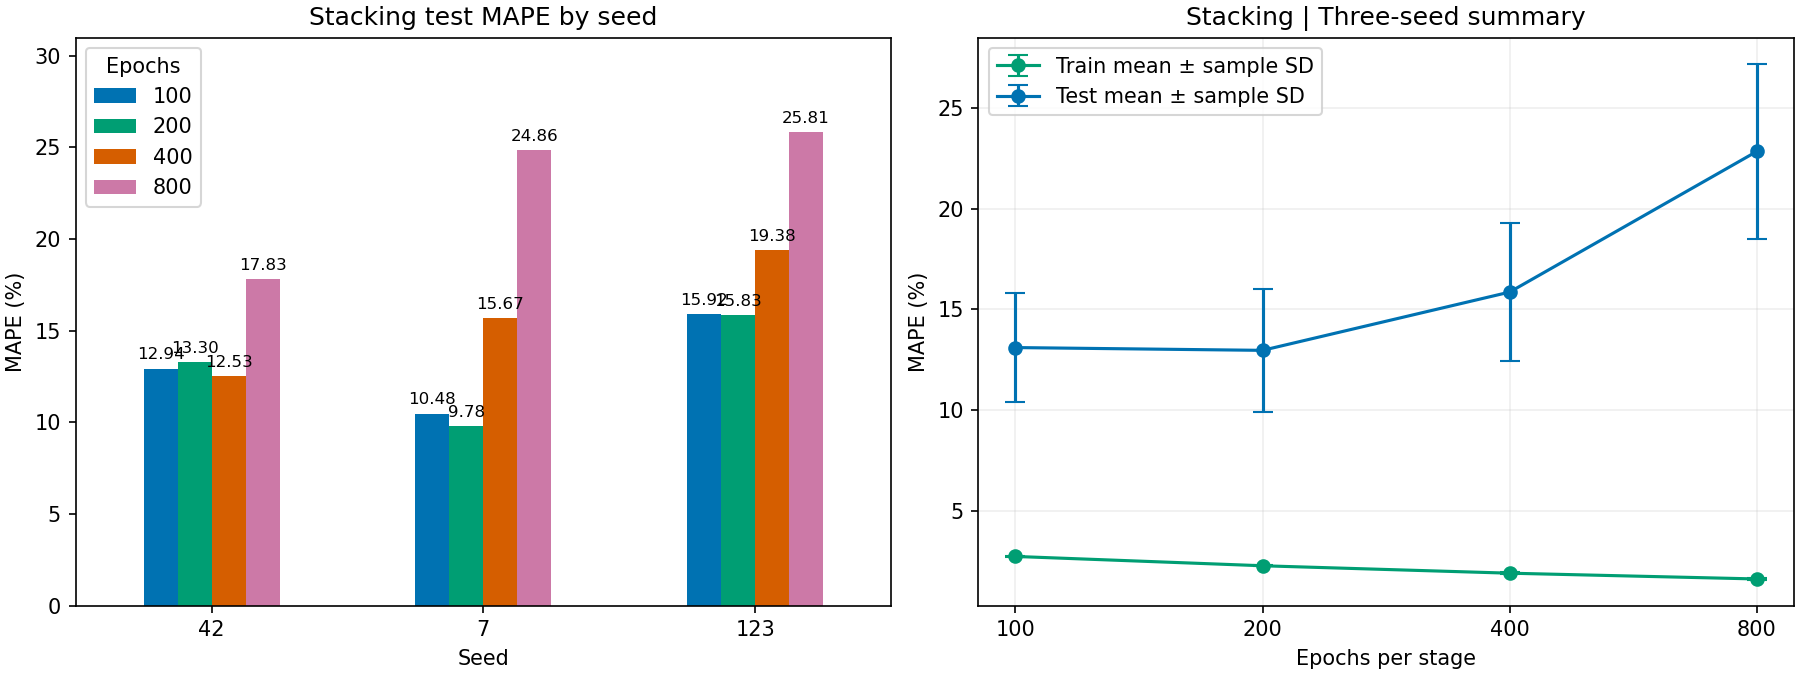

In [3]:
colors={100:'#0072B2',200:'#009E73',400:'#D55E00',800:'#CC79A7'}
fig,axes=plt.subplots(3,1,figsize=(13,10),constrained_layout=True)
for ax,seed in zip(axes,SEEDS):
    ax.plot(te,y.loc[te],color='black',lw=1.7,label='Actual')
    for budget in BUDGETS:
        g=predictions_e[(predictions_e.Seed==seed)&(predictions_e.Epochs==budget)&(predictions_e.Model=='Stacking')&(predictions_e.Split=='Test')]
        ax.plot(g.Date,g.Predicted,color=colors[budget],lw=1.1,label=f'{budget}: MAPE {comparison_e.loc[seed,budget]:.2f}%')
    ax.set(title=f'Stacking | 2020 test | Seed {seed}',ylabel='Price (dataset units)'); ax.legend(ncol=3); ax.grid(alpha=.2)
fig.savefig(OUT/'predictions_by_epochs.png',dpi=150); plt.close(fig)
display(Image(filename=str(OUT/'predictions_by_epochs.png')))
fig,axes=plt.subplots(1,2,figsize=(12,4.5),constrained_layout=True)
comparison_e.plot.bar(ax=axes[0],rot=0,color=[colors[e] for e in BUDGETS])
axes[0].set(title='Stacking test MAPE by seed',ylabel='MAPE (%)')
for c in axes[0].containers: axes[0].bar_label(c,fmt='%.2f',padding=3,fontsize=8)
axes[0].margins(y=.2)
for split,col in [('Train','#009E73'),('Test','#0072B2')]:
    g=summary_e.xs(split,level='Split').reindex(BUDGETS)
    axes[1].errorbar(range(4),g['mean'],yerr=g['std'],marker='o',capsize=5,color=col,label=split+' mean ± sample SD')
axes[1].set(xticks=range(4),xticklabels=BUDGETS,xlabel='Epochs per stage',ylabel='MAPE (%)',title='Stacking | Three-seed summary')
axes[1].legend(); axes[1].grid(alpha=.2)
fig.savefig(OUT/'epoch_comparison.png',dpi=150); plt.close(fig)
display(Image(filename=str(OUT/'epoch_comparison.png')))
monthly=predictions_e[predictions_e.Split=='Test'].copy()
monthly['Month']=monthly.Date.dt.strftime('%Y-%m')
monthly.groupby(['Month','Seed','Epochs','Model']).APE.mean().to_csv(OUT/'monthly_mape.csv')


## 轮数对比结论

| 每阶段轮数 | seed42测试MAPE | seed7测试MAPE | seed123测试MAPE | 测试均值 | 测试样本标准差 | 训练均值 |
|---|---:|---:|---:|---:|---:|---:|
|100|12.9362%|10.4800%|15.9172%|13.1111%|2.7228个百分点|2.7549%|
|200|13.3050%|9.7845%|15.8298%|12.9731%|3.0363个百分点|2.2930%|
|400|12.5285%|15.6741%|19.3820%|15.8615%|3.4306个百分点|1.9246%|
|800|17.8292%|24.8620%|25.8067%|22.8326%|4.3588个百分点|1.6387%|

- **200轮测试均值最低，但比100轮只低0.1381个百分点**，且seed42反而变差，不能认定200轮具有稳定优势。
- 400轮较100轮平均恶化2.7504个百分点；800轮恶化9.7215个百分点，三个种子在800轮均比100轮差。
- 训练MAPE从2.7549%持续降至1.6387%，测试误差却在400、800轮上升，呈现过拟合迹象。
- 同轮数下，堆叠与第一阶段基准的每个种子测试MAPE差距均不到0.23个百分点。第二阶段未明显纠正第一阶段的测试误差；本实验同时增加两个阶段轮数，不能单独归因于第二阶段训练过久。
- 这里的200轮最低是对2020测试结果的描述，不能代替独立验证集选参。所有预设结果均保留，没有按2020年结果重新训练。

100轮预测已复核与上一实验一致（最大绝对差小于1e-4）。本节结果保存于 `results/mlp_stacking_epochs_11`，包括各轮数模型权重、逐日预测、训练过程、按月MAPE及图表。


---

经测试,采用堆叠的方式,100与200轮对比基准的100轮都是有所改进的.

# 200轮：基准、堆叠、原始输入直接加入金铜收益率

三个种子42、7、123；训练截至2019年末，2020年测试；16→32隐藏层、ReLU、Adam学习率0.01、全批量，各网络200轮。

- **Base**：原7变量→股价。
- **Stacking**：Base预测＋原有6项金铜指标（各自昨日涨幅、相对5/20期均价涨幅）→股价；两个阶段各200轮，样本内训练，不用折外预测，冻结Base。
- **DirectReturns**：原7变量＋金、铜各5/20期收益率，共11项输入→股价，单阶段200轮。此处收益率沿用10：`P(t)/P(t-k)-1`，不是相对移动均价的偏离。

三组使用完全相同的有效训练/测试日期。新增20期收益率需要20条历史，较上一实验共同少1条训练记录，因此统一重新训练，不能把本次基准数值与上一实验视为完全相同。

所有标准化器只拟合共同训练集。训练损失为标准化目标MSE，另报告还原后的原股价尺度MSE（单位为数据股价单位的平方）。各轮训练MSE均为当轮更新后计算。堆叠训练MSE指第二阶段最终输出；另保留其第一阶段曲线。三组特征集合不完全相同，本实验比较具体方案，不能单独归因于堆叠结构。


In [1]:
from pathlib import Path
import os, json, hashlib, random
import numpy as np
import pandas as pd
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display, Image
ROOT=next((p for p in [Path.cwd(), *Path.cwd().parents] if (p/'src/pickle/Dataset.pkl').exists()), Path('/Users/admin/数据分析/ZiJin-Mining/ZiJin-Mining-stock-prediction-'))
OUT=Path(os.environ.get('MLP11_THREE_OUT', str(ROOT/'results/mlp_three_models_200_11')))
OUT.mkdir(parents=True,exist_ok=True)
SEEDS=[42,7,123]; EPOCHS=200; LR=0.01
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
dataset=ROOT/'src/pickle/Dataset.pkl'
d=pd.read_pickle(dataset)
raw=d['X'].copy(); target=d['Y'].copy()
assert raw.index.equals(target.index)
assert raw.index.is_unique and raw.index.is_monotonic_increasing
BASE=list(raw.columns); assert len(BASE)==7
# 截止2020年，先计算纯向后窗口，再分割，测试年初可使用2019年历史。
raw=raw.loc[raw.index.year<=2020]
y=pd.Series(np.asarray(target).reshape(-1),index=target.index,name='Actual').loc[raw.index]
x=raw.copy(); RETURNS=[]
for metal,col in [('gold','Gold Futures Price'),('copper','Copper Futures Price')]:
    name=f'{metal}_daily'; x[name]=raw[col]/raw[col].shift(1)-1; RETURNS.append(name)
    for k in [5,20]:
        name=f'{metal}_vs_ma{k}'
        x[name]=raw[col]/raw[col].rolling(k,min_periods=k).mean()-1
        RETURNS.append(name)
DIRECT=[]
for metal,col in [('gold','Gold Futures Price'),('copper','Copper Futures Price')]:
    for k in [5,20]:
        name=f'{metal}_return{k}'
        x[name]=raw[col]/raw[col].shift(k)-1
        DIRECT.append(name)
FULL=BASE+DIRECT
valid=np.isfinite(x.to_numpy()).all(axis=1)&np.isfinite(y.to_numpy())
x=x.loc[valid]; y=y.loc[x.index]
tr=x.index[x.index.year<2020]; te=x.index[x.index.year==2020]
assert len(tr)>0 and len(te)>0 and tr.max()<te.min() and (y>0).all()
splits=pd.DataFrame([dict(Split=s,N=len(idx),Start=str(idx.min().date()),End=str(idx.max().date())) for s,idx in [('Train',tr),('Test',te)]])
splits.to_csv(OUT/'splits.csv',index=False)
x.join(y).to_csv(OUT/'features_and_target.csv',index_label='Date')
config=dict(seeds=SEEDS,epochs_per_stage=EPOCHS,hidden=[16,32],activation='ReLU',optimizer='Adam',lr=LR,batch='full',train_loss='standardized target MSE',metric='MAPE percent',test_year=2020,base_features=BASE,stage2_features=['base_prediction']+RETURNS,stage2_training='in-sample predictions, no OOF',ma_includes_current=True,target='same-date original price',dataset_sha256=hashlib.sha256(dataset.read_bytes()).hexdigest(),torch_version=str(torch.__version__))
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
display(splits)
display(pd.DataFrame({'Stage2 input':config['stage2_features']}))


,Split,N,Start,End
0,Train,2034,2012-06-06,2019-12-31
1,Test,271,2020-01-01,2020-12-31


,Stage2 input
0,base_prediction
1,gold_daily
2,gold_vs_ma5
3,gold_vs_ma20
4,copper_daily
5,copper_vs_ma5
6,copper_vs_ma20


In [2]:
config['direct_features']=FULL
config['direct_return_formula']='P(t)/P(t-k)-1; k=5,20'
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
H=[]
def fit3(X,Y,seed,label):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    sx=StandardScaler().fit(X); sy=StandardScaler().fit(np.asarray(Y).reshape(-1,1))
    xt=torch.tensor(sx.transform(X),dtype=torch.float32)
    yt=torch.tensor(sy.transform(np.asarray(Y).reshape(-1,1)),dtype=torch.float32)
    model=nn.Sequential(nn.Linear(X.shape[1],16),nn.ReLU(),nn.Linear(16,32),nn.ReLU(),nn.Linear(32,1))
    opt=torch.optim.Adam(model.parameters(),lr=LR)
    for epoch in range(1,EPOCHS+1):
        model.train(); opt.zero_grad(); loss=((model(xt)-yt)**2).mean()
        assert torch.isfinite(loss); loss.backward(); opt.step(); model.eval()
        with torch.no_grad(): z=model(xt).numpy()
        p=sy.inverse_transform(z).ravel()
        mse=float(np.mean((p-np.asarray(Y))**2))
        H.append(dict(Seed=seed,Model=label,Epoch=epoch,Train_MSE=mse,Train_MSE_standardized=mse/float(sy.scale_[0]**2)))
    return model,sx,sy

def pred3(bundle,X):
    model,sx,sy=bundle; model.eval()
    with torch.no_grad(): z=model(torch.tensor(sx.transform(X),dtype=torch.float32)).numpy()
    result=sy.inverse_transform(z).ravel(); assert np.isfinite(result).all()
    return pd.Series(result,index=X.index)

rows=[]; frames=[]
for seed in SEEDS:
    base=fit3(x.loc[tr,BASE],y.loc[tr],seed,'Base')
    bp=pred3(base,x[BASE])
    meta=x[RETURNS].copy(); meta.insert(0,'base_prediction',bp)
    stack=fit3(meta.loc[tr],y.loc[tr],seed,'Stacking')
    direct=fit3(x.loc[tr,FULL],y.loc[tr],seed,'DirectReturns')
    for name,bundle,X in [('Base',base,x[BASE]),('Stacking',stack,meta),('DirectReturns',direct,x[FULL])]:
        pred=pred3(bundle,X); model,sx,sy=bundle
        torch.save(dict(state_dict=model.state_dict(),features=list(X.columns),seed=seed,epochs=EPOCHS,
            sx_mean=sx.mean_.tolist(),sx_scale=sx.scale_.tolist(),sy_mean=sy.mean_.tolist(),sy_scale=sy.scale_.tolist()),OUT/f'{name}_seed{seed}.pt')
        for split,idx in [('Train',tr),('Test',te)]:
            a=y.loc[idx].to_numpy(); p=pred.loc[idx].to_numpy(); mse=np.mean((p-a)**2)
            rows.append(dict(Seed=seed,Model=name,Split=split,N=len(idx),MAPE=100*np.mean(np.abs(p-a)/np.abs(a)),MSE=mse,MSE_standardized=mse/float(sy.scale_[0]**2)))
            frames.append(pd.DataFrame(dict(Date=idx,Seed=seed,Model=name,Split=split,Actual=a,Predicted=p)))
    print(f'Seed {seed}: all three models completed')
metrics3=pd.DataFrame(rows); history3=pd.DataFrame(H); predictions3=pd.concat(frames,ignore_index=True)
assert len(metrics3)==18 and len(history3)==1800
for row in metrics3[metrics3.Split=='Train'].itertuples():
    end=history3[(history3.Seed==row.Seed)&(history3.Model==row.Model)&(history3.Epoch==200)].iloc[0]
    assert np.isclose(end.Train_MSE,row.MSE,atol=1e-8)
metrics3.to_csv(OUT/'metrics.csv',index=False); history3.to_csv(OUT/'training_history.csv',index=False); predictions3.to_csv(OUT/'predictions.csv',index=False)
summary3=metrics3.groupby(['Model','Split'])[['MAPE','MSE','MSE_standardized']].agg(['mean','std'])
summary3.to_csv(OUT/'summary.csv')
order=['Base','Stacking','DirectReturns']
train_mse3=metrics3[metrics3.Split=='Train'].pivot(index='Seed',columns='Model',values='MSE').reindex(index=SEEDS,columns=order)
train_std3=metrics3[metrics3.Split=='Train'].pivot(index='Seed',columns='Model',values='MSE_standardized').reindex(index=SEEDS,columns=order)
test_mape3=metrics3[metrics3.Split=='Test'].pivot(index='Seed',columns='Model',values='MAPE').reindex(index=SEEDS,columns=order)
print('训练MSE（原股价尺度）：'); display(train_mse3.round(6))
print('训练MSE（标准化目标）：'); display(train_std3.round(6))
print('2020测试MAPE (%)：'); display(test_mape3.round(4))
display(summary3.round(6))


Model,Base,Stacking,DirectReturns
Seed,,,
42,0.013530,0.011930,0.011249
7,0.015786,0.013219,0.010748
123,0.014729,0.011729,0.012449


Model,Base,Stacking,DirectReturns
Seed,,,
42,0.025559,0.022535,0.021250
7,0.029820,0.024970,0.020303
123,0.027823,0.022155,0.023516


Model,Base,Stacking,DirectReturns
Seed,,,
42,12.4072,12.3425,19.6736
7,9.6460,9.9182,25.5400
123,14.9576,15.0874,12.7373


MAPE            ... MSE_standardized          
                          mean       std  ...             mean       std
Model         Split                       ...                           
Base          Test   12.336916  2.656479  ...         1.956791  0.960991
              Train   2.467689  0.065363  ...         0.027734  0.002132
DirectReturns Test   19.316966  6.408797  ...         6.881397  4.118044
              Train   2.232659  0.068482  ...         0.021690  0.001651
Stacking      Test   12.449362  2.586239  ...         1.990428  0.984008
              Train   2.296630  0.061119  ...         0.023220  0.001527

[6 rows x 6 columns]

Seed 42: all three models completed
Seed 7: all three models completed
Seed 123: all three models completed
训练MSE（原股价尺度）：
训练MSE（标准化目标）：
2020测试MAPE (%)：


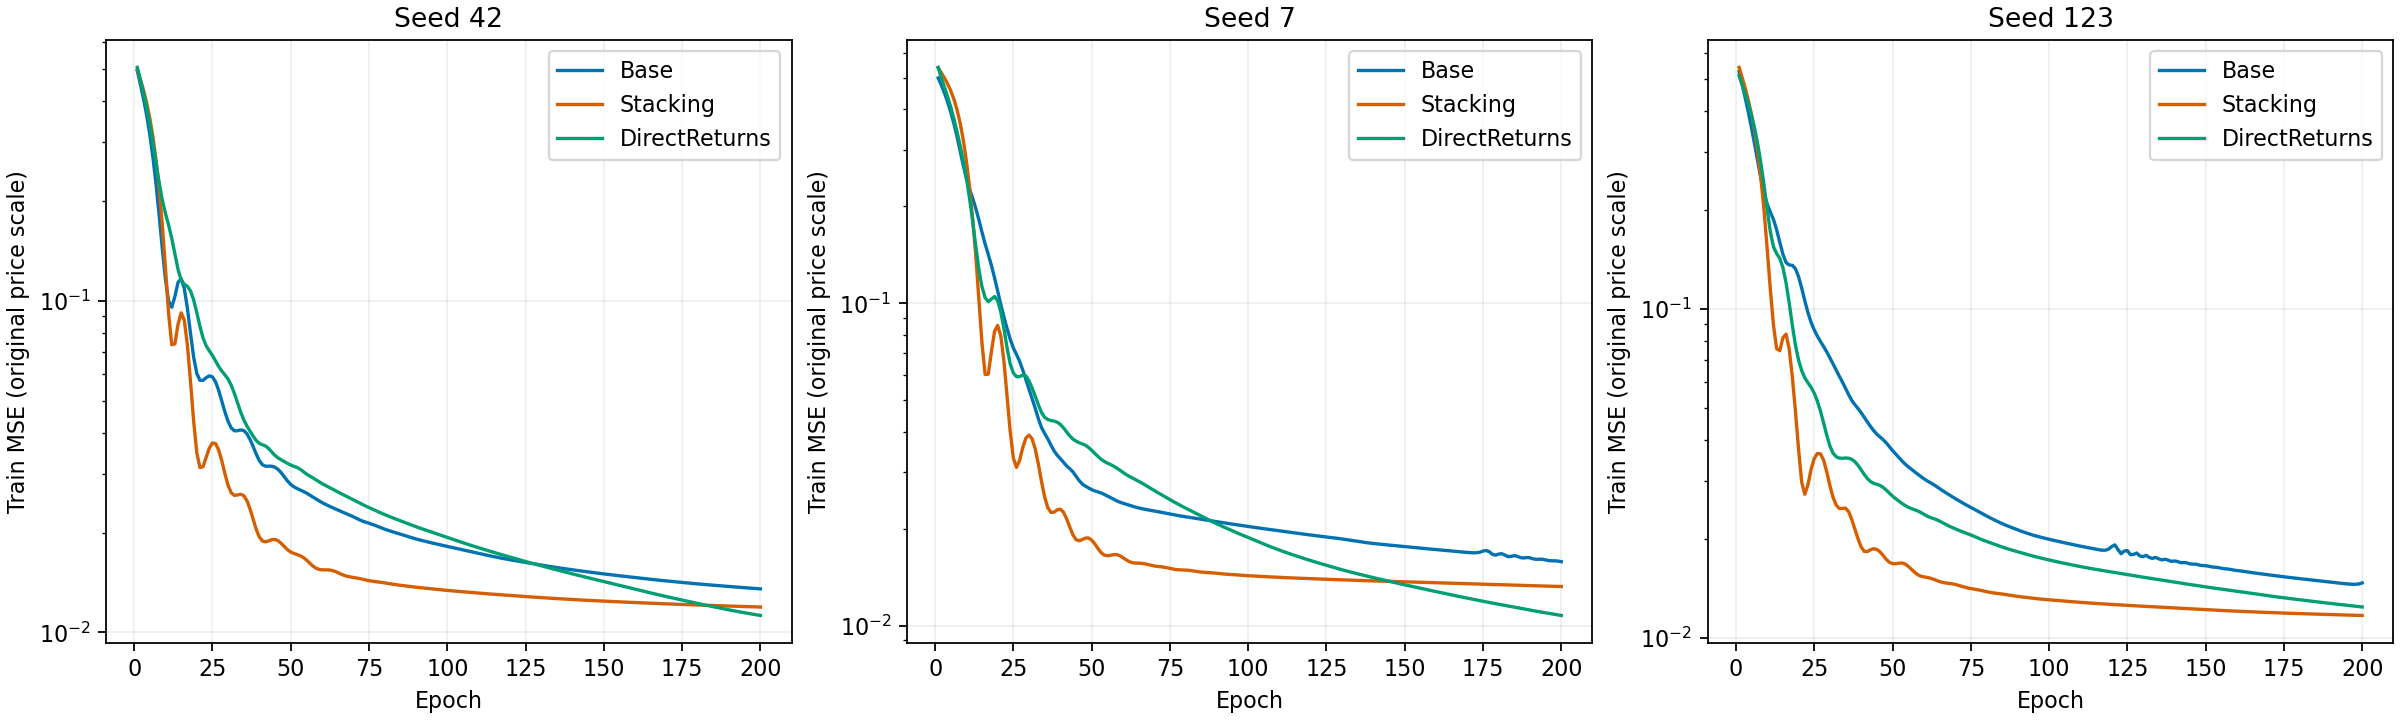

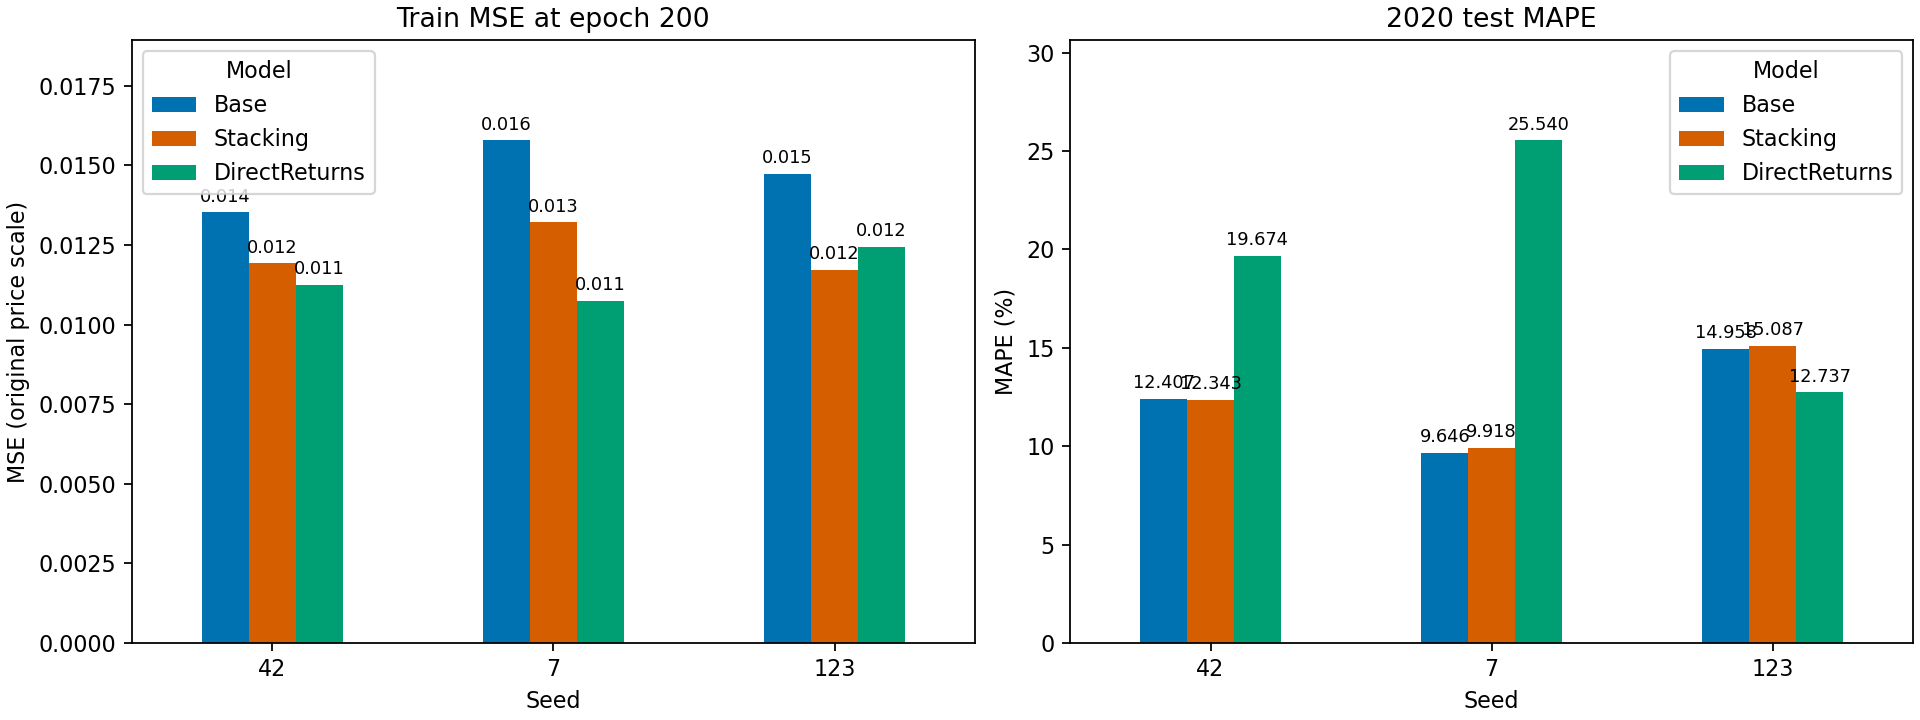

In [3]:
colors={'Base':'#0072B2','Stacking':'#D55E00','DirectReturns':'#009E73'}
fig,axes=plt.subplots(1,3,figsize=(15,4.5),constrained_layout=True)
for ax,seed in zip(axes,SEEDS):
    for name in order:
        g=history3[(history3.Seed==seed)&(history3.Model==name)]
        ax.plot(g.Epoch,g.Train_MSE,color=colors[name],label=name)
    ax.set(title=f'Seed {seed}',xlabel='Epoch',ylabel='Train MSE (original price scale)',yscale='log'); ax.grid(alpha=.2); ax.legend()
fig.savefig(OUT/'training_mse.png',dpi=160); plt.close(fig)
display(Image(filename=str(OUT/'training_mse.png')))
fig,axes=plt.subplots(1,2,figsize=(12,4.5),constrained_layout=True)
for ax,table,title,ylabel in [(axes[0],train_mse3,'Train MSE at epoch 200','MSE (original price scale)'),(axes[1],test_mape3,'2020 test MAPE','MAPE (%)')]:
    table.plot.bar(ax=ax,rot=0,color=[colors[m] for m in order])
    ax.set(title=title,ylabel=ylabel); ax.margins(y=.2)
    for c in ax.containers: ax.bar_label(c,fmt='%.3f',padding=3,fontsize=8)
fig.savefig(OUT/'comparison.png',dpi=160); plt.close(fig)
display(Image(filename=str(OUT/'comparison.png')))


## 本次三方案结果

| 模型 | 平均训练MSE（原股价尺度） | 平均训练MSE（标准化） | 平均2020测试MAPE |
|---|---:|---:|---:|
|基准 Base|0.014682|0.027734|12.3369%|
|堆叠 Stacking|0.012292|0.023220|12.4494%|
|输入直接加收益率 DirectReturns|0.011482|0.021690|19.3170%|

直接加入收益率使训练MSE最低，但2020年测试MAPE平均最高，且三个种子的测试MAPE标准差为6.4088个百分点。种子123下它优于另外两组，种子42与7下则明显更差，说明效果不稳定。堆叠相较基准降低训练MSE，但平均测试MAPE略差0.1124个百分点。

因此，这次200轮对比中，拟合训练集更好并没有转化为更好的2020年预测。三组使用共同2034条训练样本、271条测试样本。与上次相比共同剔除了一条起始训练记录，标准化和优化路径随之改变；这是本次基准结果与此前不同的原因，提示模型对样本/训练路径也有一定敏感性。

训练曲线纵轴为原股价尺度MSE，采用对数坐标。堆叠曲线横轴是第二阶段的200轮，其第一阶段已先完成200轮，不能视为三组总计算量相同。基准及直接加收益率均为单阶段200轮。


---

从图中我们看到,不同的种子下堆叠的模型在训练集上收敛最快,100轮和200轮的MSE相差不多.可以减轻训练轮数过多导致的过拟合问题.  
直接将相对变化率加入一层模型,会导致训练结果极大不稳定.

不同的种子下,即使训练收敛,不同的模型可能得到相似的结果.但是学到的模型,未必适用于新的情况,可能重要性是错的.因此,3个种子得到的平均值,可能仍然不够说明问题.

## 训练的拟合水平相近,不代表外推能力接近.

### 如果效果接近,我们应该优先选择更加简单,训练更少,不同种子更稳定的方案.

___

# 十个种子：100与200轮、三种模型

沿用最近一次三模型实验的共同样本、特征定义、架构和训练设置。种子预先固定为42、7、123、2024、2025、0、1、21、100、999。对每个种子分别运行100和200轮；相同种子、模型的100轮路径应与200轮路径的前100轮一致。

Base：7项原始输入；Stacking：基准预测＋6项金铜涨幅，两个阶段各E轮，样本内训练；DirectReturns：原7项＋金铜5/20期累计收益率，单阶段E轮。训练为2020年前的2034条共同样本，测试为2020年271条，不设验证集、不早停、不按测试结果选种子。

报告训练与测试MAPE的10种子均值、样本标准差、最小和最大值，以及逐种子200轮减100轮的配对差。训练MSE采用原股价尺度。

**收敛诊断**：对每条训练路径，比较倒数第40至21轮与最后20轮的平均MSE，计算相对下降幅度。绝对变化不超过1%标记为“末段近似平台”，下降超过1%标记为“仍在下降”，上升超过1%标记为“末段上升”。这是预先定义的局部诊断，不是数学收敛证明，也不能据此保证泛化。堆叠诊断只针对对应第一阶段冻结后的第二阶段路径。


In [1]:
from pathlib import Path
import os, json, hashlib, random
import numpy as np
import pandas as pd
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display, Image
ROOT=next((p for p in [Path.cwd(), *Path.cwd().parents] if (p/'src/pickle/Dataset.pkl').exists()), Path('/Users/admin/数据分析/ZiJin-Mining/ZiJin-Mining-stock-prediction-'))
OUT=Path(os.environ.get('MLP11_TEN_OUT', str(ROOT/'results/mlp_ten_seeds_11')))
OUT.mkdir(parents=True,exist_ok=True)
SEEDS=[42,7,123,2024,2025,0,1,21,100,999]; EPOCHS=200; LR=0.01
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
dataset=ROOT/'src/pickle/Dataset.pkl'
d=pd.read_pickle(dataset)
raw=d['X'].copy(); target=d['Y'].copy()
assert raw.index.equals(target.index)
assert raw.index.is_unique and raw.index.is_monotonic_increasing
BASE=list(raw.columns); assert len(BASE)==7
# 截止2020年，先计算纯向后窗口，再分割，测试年初可使用2019年历史。
raw=raw.loc[raw.index.year<=2020]
y=pd.Series(np.asarray(target).reshape(-1),index=target.index,name='Actual').loc[raw.index]
x=raw.copy(); RETURNS=[]
for metal,col in [('gold','Gold Futures Price'),('copper','Copper Futures Price')]:
    name=f'{metal}_daily'; x[name]=raw[col]/raw[col].shift(1)-1; RETURNS.append(name)
    for k in [5,20]:
        name=f'{metal}_vs_ma{k}'
        x[name]=raw[col]/raw[col].rolling(k,min_periods=k).mean()-1
        RETURNS.append(name)
DIRECT=[]
for metal,col in [('gold','Gold Futures Price'),('copper','Copper Futures Price')]:
    for k in [5,20]:
        name=f'{metal}_return{k}'
        x[name]=raw[col]/raw[col].shift(k)-1
        DIRECT.append(name)
FULL=BASE+DIRECT
valid=np.isfinite(x.to_numpy()).all(axis=1)&np.isfinite(y.to_numpy())
x=x.loc[valid]; y=y.loc[x.index]
tr=x.index[x.index.year<2020]; te=x.index[x.index.year==2020]
assert len(tr)>0 and len(te)>0 and tr.max()<te.min() and (y>0).all()
splits=pd.DataFrame([dict(Split=s,N=len(idx),Start=str(idx.min().date()),End=str(idx.max().date())) for s,idx in [('Train',tr),('Test',te)]])
splits.to_csv(OUT/'splits.csv',index=False)
x.join(y).to_csv(OUT/'features_and_target.csv',index_label='Date')
config=dict(seeds=SEEDS,epochs_per_stage=EPOCHS,hidden=[16,32],activation='ReLU',optimizer='Adam',lr=LR,batch='full',train_loss='standardized target MSE',metric='MAPE percent',test_year=2020,base_features=BASE,stage2_features=['base_prediction']+RETURNS,stage2_training='in-sample predictions, no OOF',ma_includes_current=True,target='same-date original price',dataset_sha256=hashlib.sha256(dataset.read_bytes()).hexdigest(),torch_version=str(torch.__version__))
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
display(splits)
display(pd.DataFrame({'Stage2 input':config['stage2_features']}))


,Split,N,Start,End
0,Train,2034,2012-06-06,2019-12-31
1,Test,271,2020-01-01,2020-12-31


,Stage2 input
0,base_prediction
1,gold_daily
2,gold_vs_ma5
3,gold_vs_ma20
4,copper_daily
5,copper_vs_ma5
6,copper_vs_ma20


In [2]:
config['direct_features']=FULL
config['epoch_budgets_per_stage']=[100,200]
config.pop('epochs_per_stage',None)
config['direct_return_formula']='P(t)/P(t-k)-1; k=5,20'
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
H=[]
def fit3(X,Y,seed,label):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    sx=StandardScaler().fit(X); sy=StandardScaler().fit(np.asarray(Y).reshape(-1,1))
    xt=torch.tensor(sx.transform(X),dtype=torch.float32)
    yt=torch.tensor(sy.transform(np.asarray(Y).reshape(-1,1)),dtype=torch.float32)
    model=nn.Sequential(nn.Linear(X.shape[1],16),nn.ReLU(),nn.Linear(16,32),nn.ReLU(),nn.Linear(32,1))
    opt=torch.optim.Adam(model.parameters(),lr=LR)
    for epoch in range(1,EPOCHS+1):
        model.train(); opt.zero_grad(); loss=((model(xt)-yt)**2).mean()
        assert torch.isfinite(loss); loss.backward(); opt.step(); model.eval()
        with torch.no_grad(): z=model(xt).numpy()
        p=sy.inverse_transform(z).ravel()
        mse=float(np.mean((p-np.asarray(Y))**2))
        H.append(dict(Seed=seed,Budget=EPOCHS,Model=label,Epoch=epoch,Train_MSE=mse,Train_MSE_standardized=mse/float(sy.scale_[0]**2)))
    return model,sx,sy

def pred3(bundle,X):
    model,sx,sy=bundle; model.eval()
    with torch.no_grad(): z=model(torch.tensor(sx.transform(X),dtype=torch.float32)).numpy()
    result=sy.inverse_transform(z).ravel(); assert np.isfinite(result).all()
    return pd.Series(result,index=X.index)

rows=[]; frames=[]
for EPOCHS in [100,200]:
    for seed in SEEDS:
        base=fit3(x.loc[tr,BASE],y.loc[tr],seed,'Base')
        bp=pred3(base,x[BASE])
        meta=x[RETURNS].copy(); meta.insert(0,'base_prediction',bp)
        stack=fit3(meta.loc[tr],y.loc[tr],seed,'Stacking')
        direct=fit3(x.loc[tr,FULL],y.loc[tr],seed,'DirectReturns')
        for name,bundle,X in [('Base',base,x[BASE]),('Stacking',stack,meta),('DirectReturns',direct,x[FULL])]:
            pred=pred3(bundle,X); model,sx,sy=bundle
            torch.save(dict(state_dict=model.state_dict(),features=list(X.columns),seed=seed,epochs=EPOCHS,
                sx_mean=sx.mean_.tolist(),sx_scale=sx.scale_.tolist(),sy_mean=sy.mean_.tolist(),sy_scale=sy.scale_.tolist()),OUT/f'{name}_{EPOCHS}_seed{seed}.pt')
            for split,idx in [('Train',tr),('Test',te)]:
                a=y.loc[idx].to_numpy(); p=pred.loc[idx].to_numpy(); mse=np.mean((p-a)**2)
                rows.append(dict(Seed=seed,Budget=EPOCHS,Model=name,Split=split,N=len(idx),MAPE=100*np.mean(np.abs(p-a)/np.abs(a)),MSE=mse,MSE_standardized=mse/float(sy.scale_[0]**2)))
                frames.append(pd.DataFrame(dict(Date=idx,Seed=seed,Budget=EPOCHS,Model=name,Split=split,Actual=a,Predicted=p)))
        print(f'{EPOCHS} epochs / seed {seed}: completed',flush=True)


100 epochs / seed 42: completed
100 epochs / seed 7: completed
100 epochs / seed 123: completed
100 epochs / seed 2024: completed
100 epochs / seed 2025: completed
100 epochs / seed 0: completed
100 epochs / seed 1: completed
100 epochs / seed 21: completed
100 epochs / seed 100: completed
100 epochs / seed 999: completed
200 epochs / seed 42: completed
200 epochs / seed 7: completed
200 epochs / seed 123: completed
200 epochs / seed 2024: completed
200 epochs / seed 2025: completed
200 epochs / seed 0: completed
200 epochs / seed 1: completed
200 epochs / seed 21: completed
200 epochs / seed 100: completed
200 epochs / seed 999: completed


In [3]:
metrics10=pd.DataFrame(rows); history10=pd.DataFrame(H); predictions10=pd.concat(frames,ignore_index=True)
assert len(metrics10)==120 and len(history10)==9000
assert np.isfinite(metrics10[['MSE','MAPE']]).all().all()
metrics10.to_csv(OUT/'metrics.csv',index=False); history10.to_csv(OUT/'training_history.csv',index=False); predictions10.to_csv(OUT/'predictions.csv',index=False)
# 同种子Base/DirectReturns，两预算前100轮完全一致；Stacking因第一阶段不同不适用。
for seed in SEEDS:
    for name in ['Base','DirectReturns']:
        a=history10[(history10.Seed==seed)&(history10.Model==name)&(history10.Budget==100)].Train_MSE.to_numpy()
        b=history10[(history10.Seed==seed)&(history10.Model==name)&(history10.Budget==200)&(history10.Epoch<=100)].Train_MSE.to_numpy()
        assert np.allclose(a,b,rtol=0,atol=1e-12)
for r in metrics10[metrics10.Split=='Train'].itertuples():
    h=history10[(history10.Seed==r.Seed)&(history10.Model==r.Model)&(history10.Budget==r.Budget)]
    assert np.isclose(h.iloc[-1].Train_MSE,r.MSE,atol=1e-8)
summary10=metrics10.groupby(['Model','Budget','Split'])[['MAPE','MSE']].agg(['mean','std','min','max'])
summary10.to_csv(OUT/'summary.csv')
paired10=metrics10.pivot(index=['Model','Seed','Split'],columns='Budget',values='MAPE')
paired10['delta_200_minus_100_pp']=paired10[200]-paired10[100]
paired10.to_csv(OUT/'paired_mape.csv')
diagnostics=[]
for (name,seed,budget),g in history10.groupby(['Model','Seed','Budget']):
    g=g.sort_values('Epoch'); prev=g.iloc[-40:-20].Train_MSE.mean(); last=g.iloc[-20:].Train_MSE.mean()
    change=100*(prev-last)/prev
    status='plateau' if abs(change)<=1 else ('decreasing' if change>1 else 'increasing')
    diagnostics.append(dict(Model=name,Seed=seed,Budget=budget,Initial_MSE=g.iloc[0].Train_MSE,Final_MSE=g.iloc[-1].Train_MSE,Previous20_mean=prev,Last20_mean=last,Decrease_percent=change,Status=status))
diagnostics10=pd.DataFrame(diagnostics); diagnostics10.to_csv(OUT/'convergence_diagnostics.csv',index=False)
counts10=diagnostics10.groupby(['Model','Budget','Status']).size().unstack(fill_value=0)
counts10.to_csv(OUT/'convergence_counts.csv')
print('训练与测试MAPE / MSE汇总：'); display(summary10.round(6))
print('末段训练损失状态（decreasing仍下降、plateau近似平台、increasing上升）：'); display(counts10)
print('2020逐种子MAPE：'); display(metrics10[metrics10.Split=='Test'].pivot(index='Seed',columns=['Model','Budget'],values='MAPE').reindex(SEEDS).round(4))
# 200轮的前三个种子应复现前一组三模型实验。
prior=OUT.parent/'mlp_three_models_200_11/metrics.csv'
if prior.exists():
    old=pd.read_csv(prior)
    check=old.merge(metrics10[metrics10.Budget==200],on=['Seed','Model','Split'],suffixes=('_old','_new'),validate='one_to_one')
    assert len(check)==18 and np.allclose(check.MSE_old,check.MSE_new,atol=1e-8)
    print('已验证：200轮前三个种子复现上一实验；Base及DirectReturns的100/200轮前缀训练路径一致。')


MAPE            ...       MSE          
                                 mean       std  ...       min       max
Model         Budget Split                       ...                    
Base          100    Test   13.455135  2.313884  ...  0.657458  2.378045
                     Train   2.920769  0.136729  ...  0.018173  0.023027
              200    Test   13.392170  2.809083  ...  0.510124  2.528241
                     Train   2.472409  0.106021  ...  0.013530  0.016759
DirectReturns 100    Test   17.251772  2.903796  ...  1.361292  3.788951
                     Train   2.729403  0.131575  ...  0.014648  0.019320
              200    Test   18.155862  4.323921  ...  1.193851  5.834548
                     Train   2.169309  0.097419  ...  0.009232  0.012449
Stacking      100    Test   13.475685  2.222054  ...  0.671365  2.256593
                     Train   2.808547  0.099954  ...  0.016957  0.020516
              200    Test   13.417428  2.734295  ...  0.508657  2.508771
                     Train   2.307092  0.072715  ...  0.011729  0.013407

[12 rows x 8 columns]

Status                decreasing  plateau
Model         Budget                     
Base          100             10        0
              200             10        0
DirectReturns 100             10        0
              200             10        0
Stacking      100             10        0
              200              8        2

Model,Base,Stacking,DirectReturns,Base,Stacking,DirectReturns
Budget,100,100,100,200,200,200
Seed,,,,,,
42,13.2110,13.3317,15.6667,12.4072,12.3425,19.6736
7,10.6303,10.5862,20.2429,9.6460,9.9182,25.5400
123,16.2439,16.0592,15.1280,14.9576,15.0874,12.7373
2024,16.1863,15.8687,17.7091,15.5916,15.4773,17.6962
2025,13.0587,13.0880,14.4892,14.4329,14.3172,14.9738
0,13.5138,13.9353,19.8060,12.7192,12.8782,19.2037
1,14.9411,14.7196,19.5739,17.9489,17.7691,22.2020
21,11.0139,11.0528,11.7255,11.3903,11.4737,10.9871


训练与测试MAPE / MSE汇总：
末段训练损失状态（decreasing仍下降、plateau近似平台、increasing上升）：
2020逐种子MAPE：
已验证：200轮前三个种子复现上一实验；Base及DirectReturns的100/200轮前缀训练路径一致。


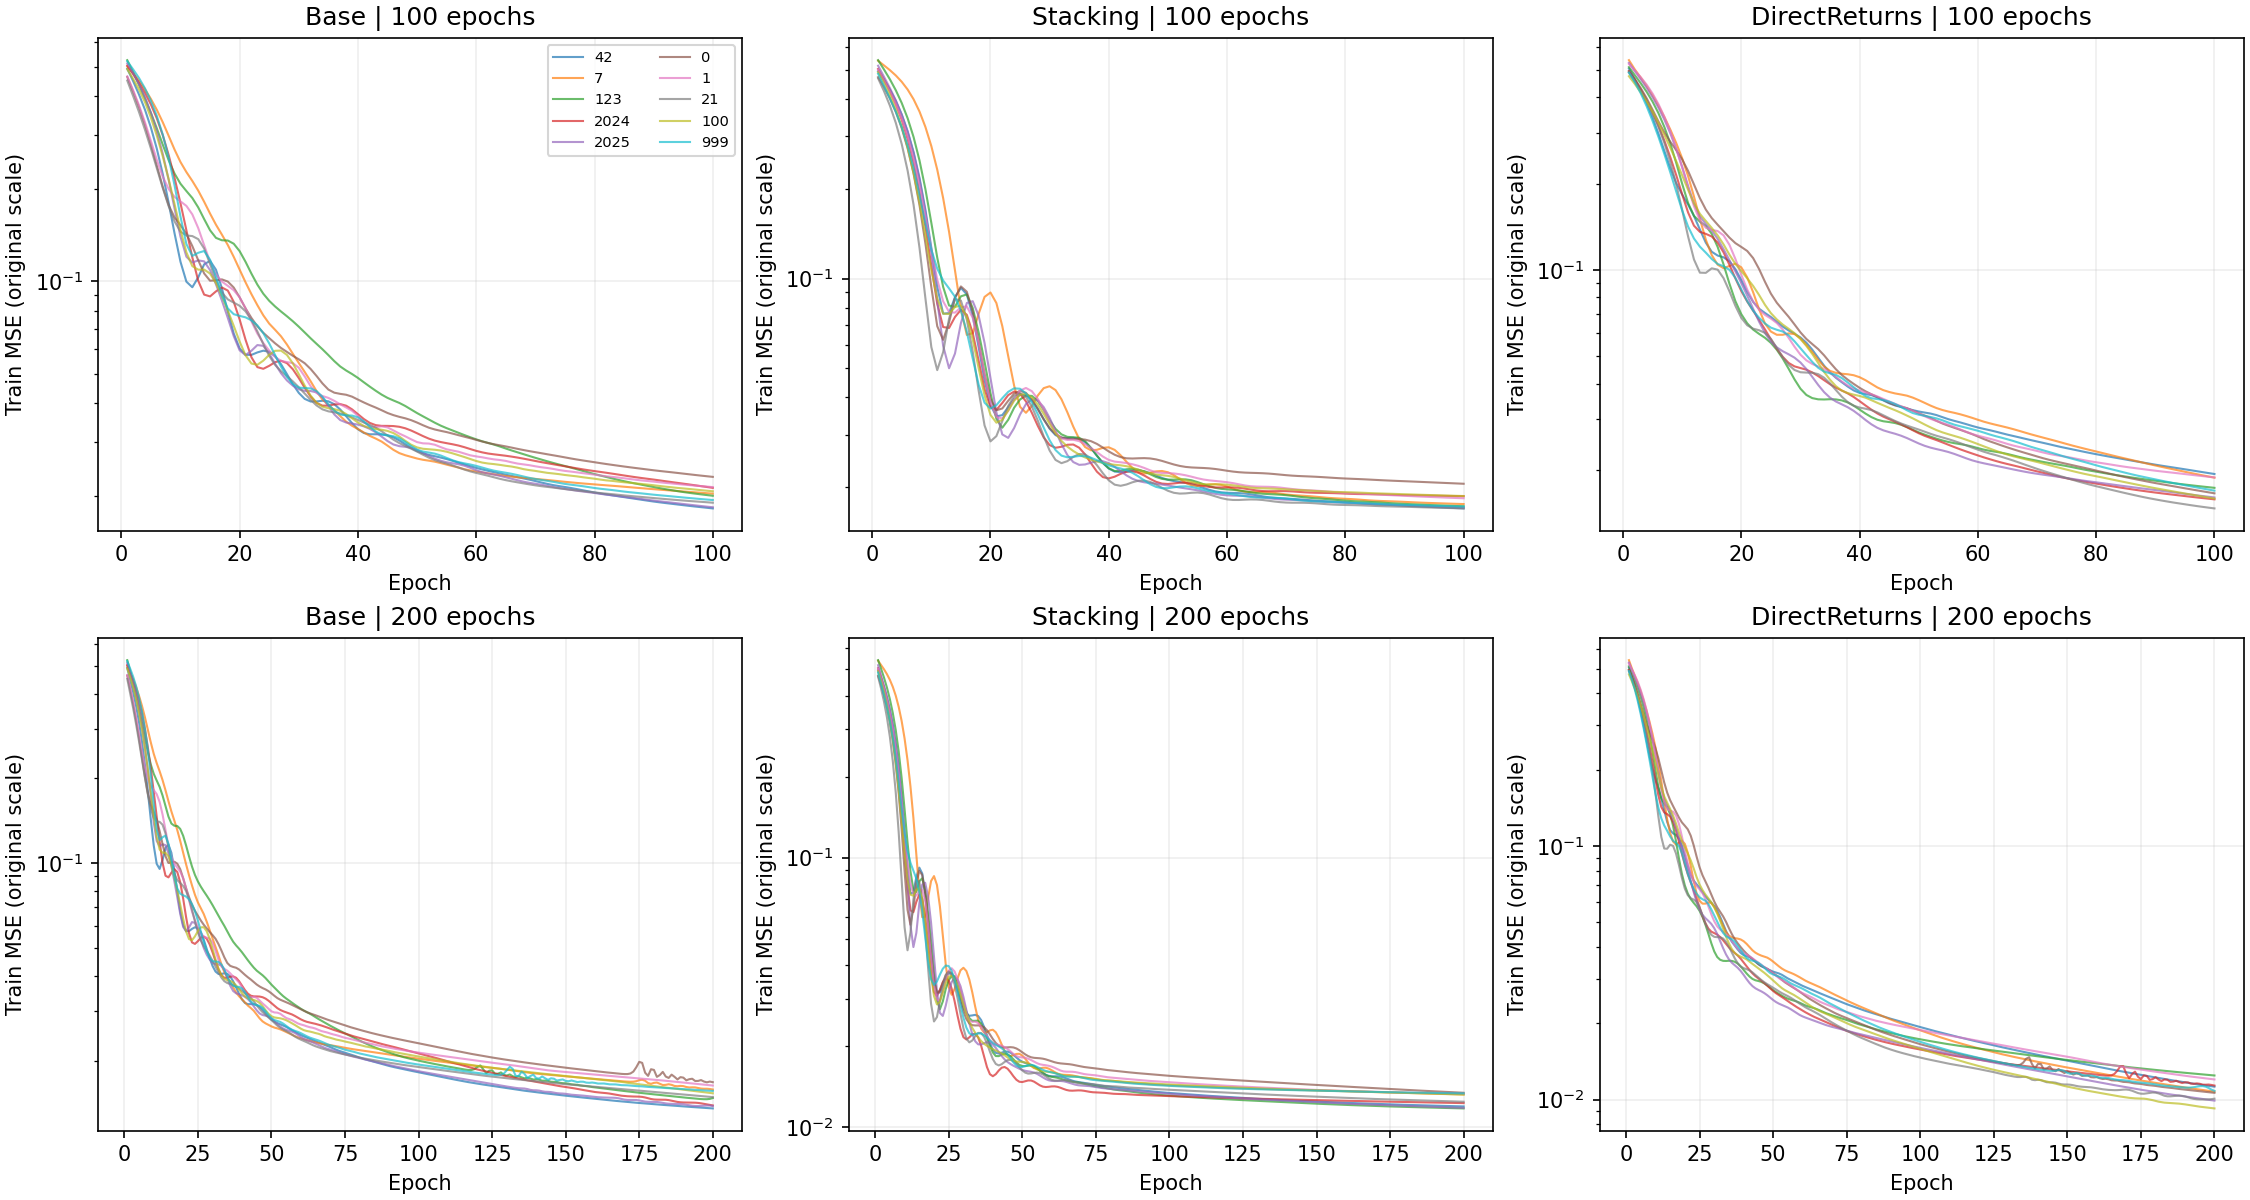

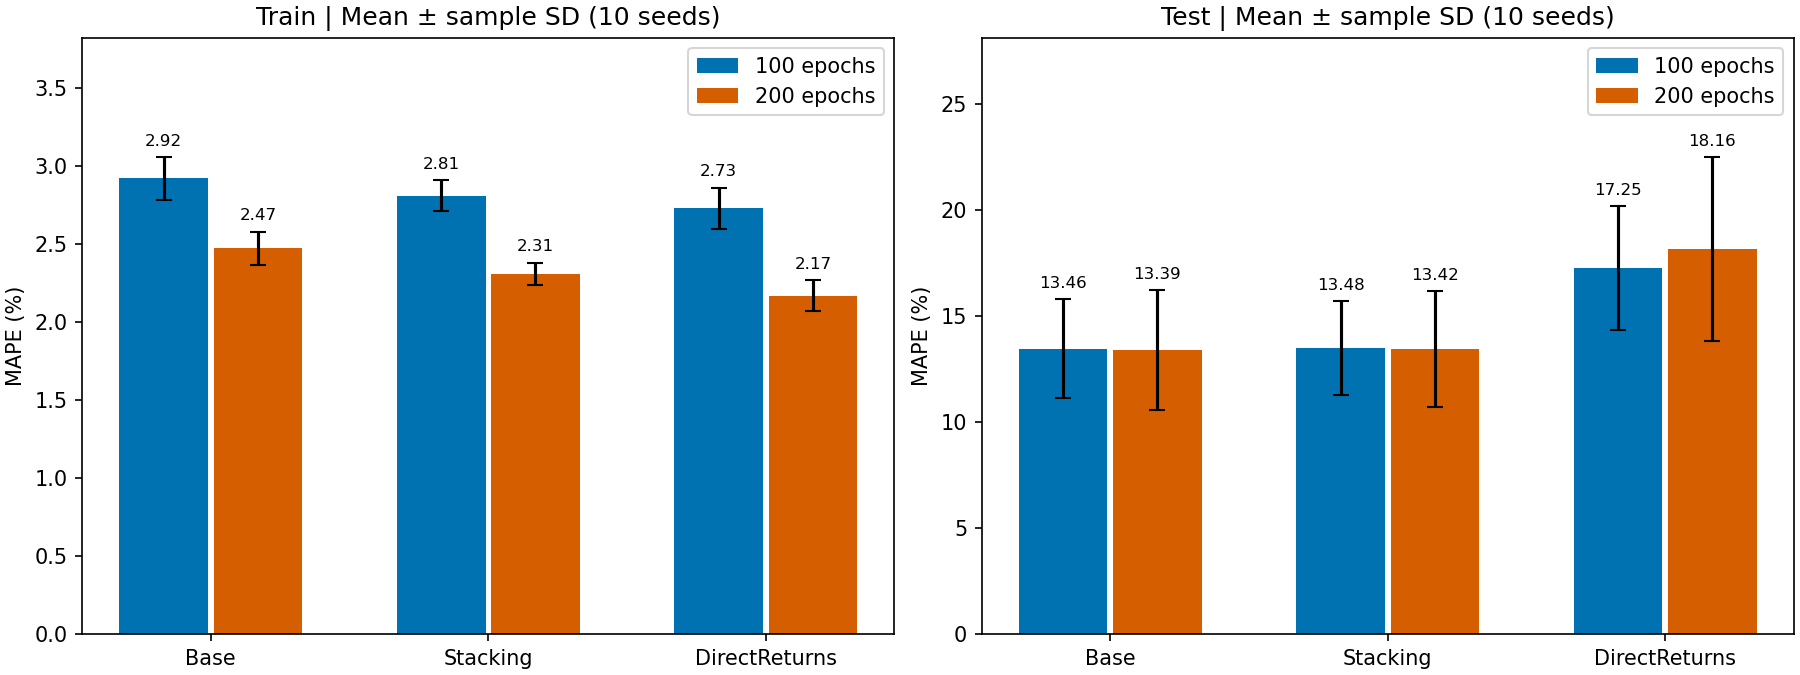

In [4]:
order=['Base','Stacking','DirectReturns']; colors={100:'#0072B2',200:'#D55E00'}
fig,axes=plt.subplots(2,3,figsize=(15,8),constrained_layout=True)
for j,name in enumerate(order):
    for i,budget in enumerate([100,200]):
        ax=axes[i,j]
        for seed in SEEDS:
            g=history10[(history10.Model==name)&(history10.Budget==budget)&(history10.Seed==seed)]
            ax.plot(g.Epoch,g.Train_MSE,lw=1,alpha=.7,label=str(seed))
        ax.set(title=f'{name} | {budget} epochs',xlabel='Epoch',ylabel='Train MSE (original scale)',yscale='log'); ax.grid(alpha=.2)
axes[0,0].legend(ncol=2,fontsize=7)
fig.savefig(OUT/'training_mse_ten_seeds.png',dpi=150); plt.close(fig)
display(Image(filename=str(OUT/'training_mse_ten_seeds.png')))
fig,axes=plt.subplots(1,2,figsize=(12,4.5),constrained_layout=True)
for ax,split in zip(axes,['Train','Test']):
    for offset,budget in [(-.17,100),(.17,200)]:
        g=metrics10[(metrics10.Split==split)&(metrics10.Budget==budget)].groupby('Model').MAPE.agg(['mean','std']).reindex(order)
        bars=ax.bar(np.arange(3)+offset,g['mean'],width=.32,yerr=g['std'],capsize=4,color=colors[budget],label=f'{budget} epochs')
        ax.bar_label(bars,fmt='%.2f',padding=4,fontsize=8)
    ax.set(xticks=np.arange(3),xticklabels=order,ylabel='MAPE (%)',title=split+' | Mean ± sample SD (10 seeds)'); ax.legend(); ax.margins(y=.25)
fig.savefig(OUT/'mape_comparison.png',dpi=150); plt.close(fig)
display(Image(filename=str(OUT/'mape_comparison.png')))


## 十种子实验结论

| 模型 | 每阶段轮数 | 平均训练MSE（原尺度） | 平均训练MAPE | 平均测试MAPE ± 种子样本标准差 |
|---|---:|---:|---:|---:|
|基准|100|0.020134|2.9208%|13.4551% ± 2.3139个百分点|
|基准|200|0.015053|2.4724%|13.3922% ± 2.8091个百分点|
|堆叠|100|0.017912|2.8085%|13.4757% ± 2.2221个百分点|
|堆叠|200|0.012657|2.3071%|13.4174% ± 2.7343个百分点|
|直接加收益率|100|0.016986|2.7294%|17.2518% ± 2.9038个百分点|
|直接加收益率|200|0.010850|2.1693%|18.1559% ± 4.3239个百分点|

所有种子均完成训练，最终损失有限、相近，没有出现数值发散。但这不意味着全部收敛：按预设的末段20轮均值比较标准，100轮时30组均仍在下降；200轮时基准和直接加收益率各10组均仍下降，堆叠8组仍下降、2组近似平台。

200轮末段相对于前20轮的MSE平均降幅：基准4.54%，堆叠1.48%，直接加收益率6.89%。训练拟合还在改善，但不等于测试结果会改善。

同种子配对比较，200轮相对100轮：基准测试MAPE平均降低0.0630个百分点（7/10改善），堆叠降低0.0583个百分点（7/10改善），直接加收益率平均升高0.9041个百分点（5/10改善、5/10变差）。三种模型的200轮测试MAPE种子标准差均高于100轮。

这批2020年结果没有显示把100轮增加到200轮的明确收益，也没有显示堆叠比基准更好；直接加收益率虽训练误差更低，平均测试误差却更高。若优先考虑简洁和稳定，100轮基准值得作为后续验证候选，但本实验没有验证集，不能把2020年的比较当作独立验证选参。

标准差描述种子之间的波动，不是均值的置信区间；均值为逐种子MAPE平均，并非把十个模型预测先平均后的集成误差。所有结果保存在 `results/mlp_ten_seeds_11`。


---

从20年的实验来看,基准和堆叠的情况下,100轮与200轮相差不大.默认选择100轮.